# Interactive Optimization with ADM and Pymoo-based Problem Server

This notebook demonstrates how to use an ADM framework to interactively solve benchmark problems (DTLZ, WFG) exposed through a FastAPI problem server.

## 1. Introduction

This notebook demonstrates how to connect to a FastAPI-based *Problem Server* that exposes
multi-objective benchmark problems (e.g., DTLZ and WFG families) through a REST API.

⚠️ **Important:** Before running this notebook, make sure the problem server (` desdeo\problem\testproblems\benchmark_server.py`) is running locally.

You can start it by opening a terminal and running:

```bash
python benchmark_server.py
```

The server should be accessible at `http://127.0.0.1:8000`.

Once the server is up, this notebook will:

1. Connect to it to create problem instances via `server_problem()`.
2. Dynamically generate DTLZ and WFG problems with customizable numbers of objectives and variables.
3. Solve them using the Artificial Decision Maker (ADM) framework and interactive evolutionary algorithms (NSGA-III and RVEA).
4. Visualize the ADM’s learning and decision phases.

## 2. Imports and setup


In [5]:
import pandas as pd
from desdeo.problem import Problem
from desdeo.emo.methods.EAs import ReferenceVectorOptions
from desdeo.adm.ADMAfsar import ADMAfsar
import time
import os
from desdeo.emo.options.selection import NSGA3SelectorOptions, RVEASelectorOptions
from desdeo.emo.options.termination import MaxGenerationsTerminatorOptions
from utils import get_default_ea_parameters, create_problem

from desdeo.emo import (
    algorithms,
    generator,
    preference_handling,
)

# -- Configuration: Server URL and port
SERVER_URL = "http://127.0.0.1"
SERVER_PORT = 8000

OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IT_LEARNING = 4
IT_DECISION = 3


Run ADM-based interactive optimization for one problem.

In [6]:
from desdeo.emo.options.generator import LHSGeneratorOptions


def run_adm_optimization(problem: Problem) -> pd.DataFrame:
    n_obj = len(problem.objectives)
    symbols = [f"{x.symbol}" for x in problem.objectives]
    reference_points = []
    pop_size, n_gen, pymoo_layers = get_default_ea_parameters(problem.name, n_obj)

    # Initialize ADM
    adm = ADMAfsar(
        problem=problem,
        it_learning_phase=IT_LEARNING,
        it_decision_phase=IT_DECISION,
        reference_vector_options=ReferenceVectorOptions(
            creation_type="multi_layer",
            pymoo_layers=pymoo_layers
        ),
        true_ideal=problem.get_ideal_point(),
        true_nadir=problem.get_nadir_point(),
    )

    # Initial solvers
    rvea_opts = algorithms.rvea_options()
    nsga3_opts = algorithms.nsga3_options()

    rvea_opts.template.generator=LHSGeneratorOptions(n_points=pop_size, name='LHSGenerator')
    rvea_opts.template.termination = MaxGenerationsTerminatorOptions(name='MaxGenerationsTerminator', max_generations=n_gen)        
    rvea_opts.template.selection = RVEASelectorOptions(
        name='RVEASelector',
        reference_vector_options=ReferenceVectorOptions(
            creation_type="multi_layer",
            pymoo_layers=pymoo_layers,
        ),
        invert_reference_vectors=False
    )
    #rvea_opts.template.use_archive=False
    
    nsga3_opts.template.generator=LHSGeneratorOptions(n_points=pop_size, name='LHSGenerator')
    nsga3_opts.template.termination = MaxGenerationsTerminatorOptions(name='MaxGenerationsTerminator', max_generations=n_gen)
    nsga3_opts.template.selection = NSGA3SelectorOptions(
        name='NSGA3Selector',
        reference_vector_options=ReferenceVectorOptions(
            creation_type="multi_layer",
            pymoo_layers=pymoo_layers,
        ),
        invert_reference_vectors=False
    )
    #nsga3_opts.template.use_archive=False

    rvea, extras_rvea = algorithms.emo_constructor(
        emo_options=rvea_opts,
        problem=problem
        
    )
    nsga3, extras_nsga3 = algorithms.emo_constructor(
        emo_options=nsga3_opts,
        problem=problem
    )

    results_rvea = rvea()
    results_nsga3 = nsga3()


    iteration = 0
    while adm.has_next():
        iteration += 1
        solutions_rvea = results_rvea.optimal_variables
        solutions_nsga3 = results_nsga3.optimal_variables
        outputs_rvea = results_rvea.optimal_outputs
        outputs_nsga3 = results_nsga3.optimal_outputs

        front_rvea = results_rvea.optimal_outputs.select([symbols[i] for i in range(n_obj)]).to_numpy()
        front_nsga3 = results_nsga3.optimal_outputs.select([symbols[i] for i in range(n_obj)]).to_numpy()

        # Update ADM preference
        adm.get_next_preference(front_rvea, front_nsga3)
       
        # Determine phase
        phase = "L" if iteration <= IT_LEARNING else "D"

        # Store reference point with phase
        reference_points.append(list(adm.preference) + [phase])

        print(f"Iteration {iteration} | Phase: {phase} | Preference: {adm.preference} § shape: {adm.preference.shape}")
        print(f"RVEA front shape: {front_rvea.shape} | NSGA-III front shape: {front_nsga3.shape}")
        preferences_nsga3 = preference_handling.ReferencePointOptions(
            preference=dict(zip(symbols, adm.preference)),
            method="Hakanen"
        )

        preferences_rvea = preference_handling.ReferencePointOptions(
            preference=dict(zip(symbols, adm.preference)),
            method="IOPIS"
        )

        rvea_opts.template.generator = generator.ArchiveGeneratorOptions(solutions=solutions_rvea, outputs=outputs_rvea)
        nsga3_opts.template.generator = generator.ArchiveGeneratorOptions(solutions=solutions_nsga3, outputs=outputs_nsga3)

        rvea_opts.preference = preferences_rvea
        nsga3_opts.preference = preferences_nsga3

        nsga3_archive, extras_archive = algorithms.emo_constructor(
            emo_options=nsga3_opts,
            problem=problem
        )
        rvea_archive, extras_archive = algorithms.emo_constructor(
            emo_options=rvea_opts,
            problem=problem
        )

        results_nsga3 = nsga3_archive()
        results_rvea = rvea_archive()

        results_nsga3.optimal_outputs.write_csv(os.path.join(OUTPUT_DIR, f"nsga3_iteration_{problem.name}_{len(problem.objectives)}_{iteration}.csv"))
        results_rvea.optimal_outputs.write_csv(os.path.join(OUTPUT_DIR, f"rvea_iteration_{problem.name}_{len(problem.objectives)}_{iteration}.csv"))
        phase = "Learning" if iteration <= IT_LEARNING else "Decision"

    # Convert to DataFrame
    columns = [f"f_{i+1}" for i in range(n_obj)] + ["Phase"]

    df_ref = pd.DataFrame(reference_points, columns=columns)
    return df_ref

In [7]:
# # 6. Run All Experiments

dtlz_problems = [f"dtlz{i}" for i in range(6, 8)]
wfg_problems = [f"wfg{i}" for i in range(1, 10)]
objective_counts = [3, 5, 7]

total = len(wfg_problems ) * len(objective_counts)
counter = 0

start_time = time.time()
for name in wfg_problems:
    for n_obj in objective_counts:
        counter += 1
        print(f"\n--- [{counter}/{total}] Running {name.upper()} with {n_obj} objectives ---")
        problem = create_problem(name, n_obj)
        reference_points = run_adm_optimization(problem)
        out_path = os.path.join(OUTPUT_DIR, f"{name}_{n_obj}obj_refpoints.csv")
        reference_points.to_csv(out_path, index=False)
        print(f"💾 Saved {len(reference_points)} reference points → {out_path}")

elapsed = (time.time() - start_time) / 60
print(f"\n✅ Completed all experiments in {elapsed:.2f} minutes.")



--- [1/27] Running WFG1 with 3 objectives ---
✅ Created WFG1 with 24 vars and 3 objectives.


C:\Users\Giomara\Documents\Projects\GECCO_journal\DESDEO\desdeo\emo\options\selection.py:114: UserWarning: Adaptation frequency was set to 0. Setting it to 100 for RVEA selector. Set it to 0 only if you provide preference information.
  return selection_types[name](problem=problem, publisher=publisher, seed=seed, verbosity=verbosity, **options)
C:\Users\Giomara\Documents\Projects\GECCO_journal\DESDEO\desdeo\emo\operators\mutation.py:141: RuntimeWarning: invalid value encountered in power
  (2 * miu[temp] + (1 - 2 * miu[temp]) * (1 - offspring_scaled[temp]) ** (self.distribution_index + 1))


EvaluatorError: Failed to call the simulator at url='http://127.0.0.1:8000/evaluate' auth=None. Is the simulator server running?

# Visualizing the results

<Figure size 800x600 with 0 Axes>

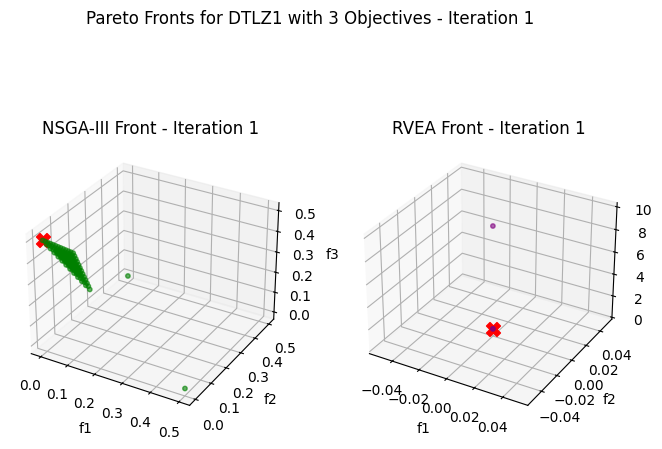

<Figure size 640x480 with 0 Axes>

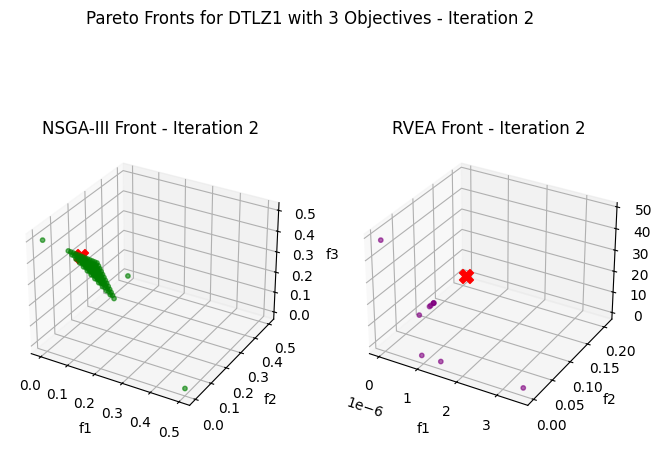

<Figure size 640x480 with 0 Axes>

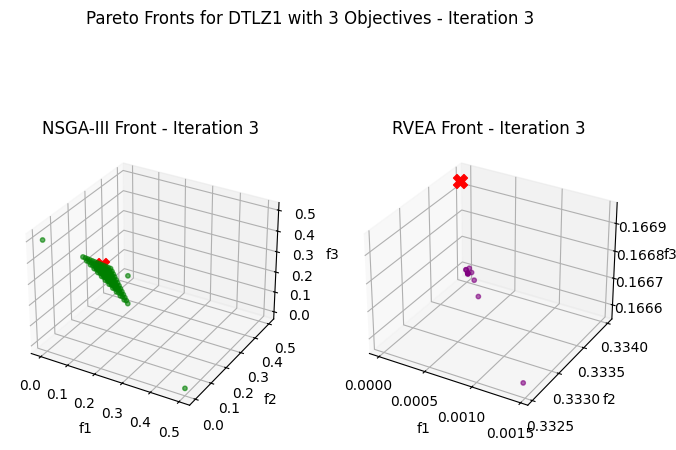

<Figure size 640x480 with 0 Axes>

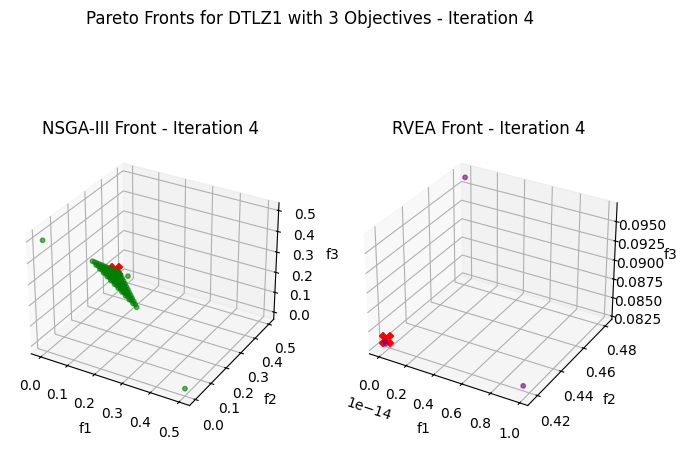

<Figure size 640x480 with 0 Axes>

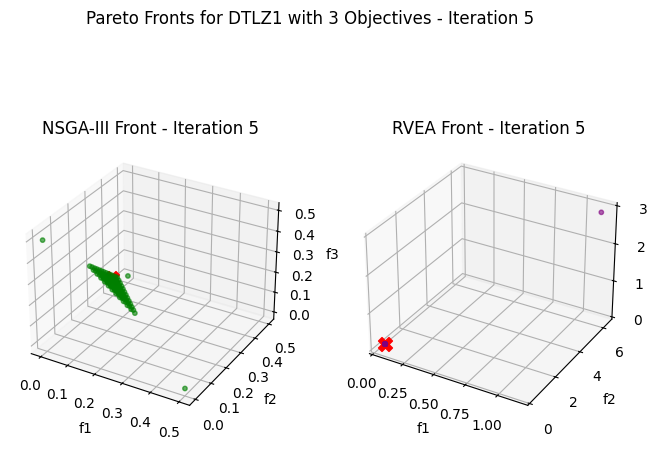

<Figure size 640x480 with 0 Axes>

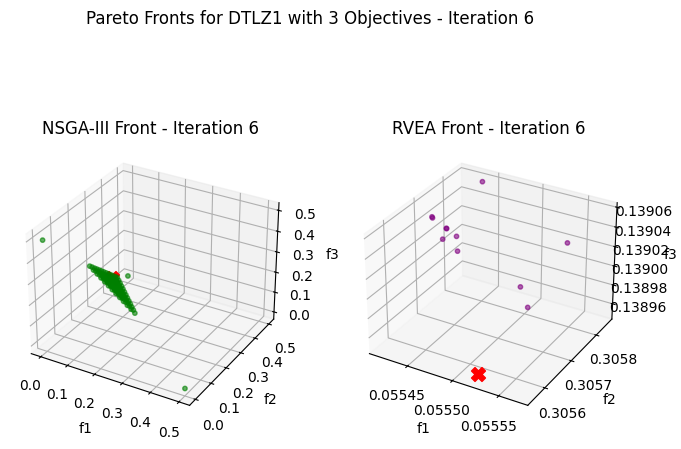

<Figure size 640x480 with 0 Axes>

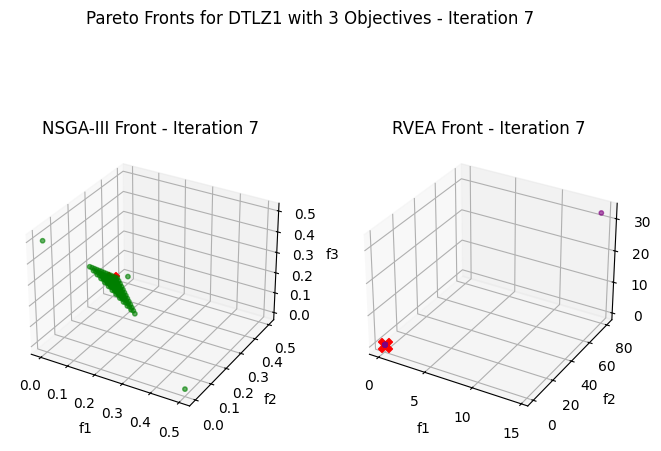

<Figure size 800x600 with 0 Axes>

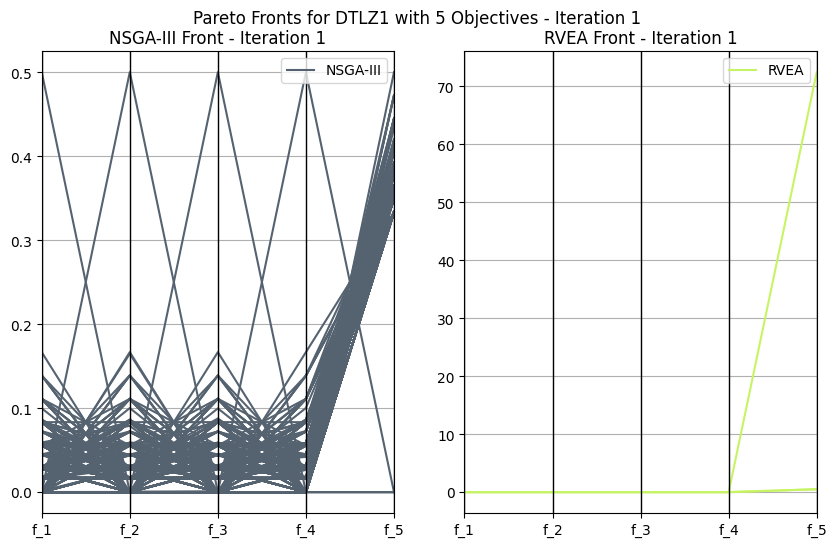

<Figure size 640x480 with 0 Axes>

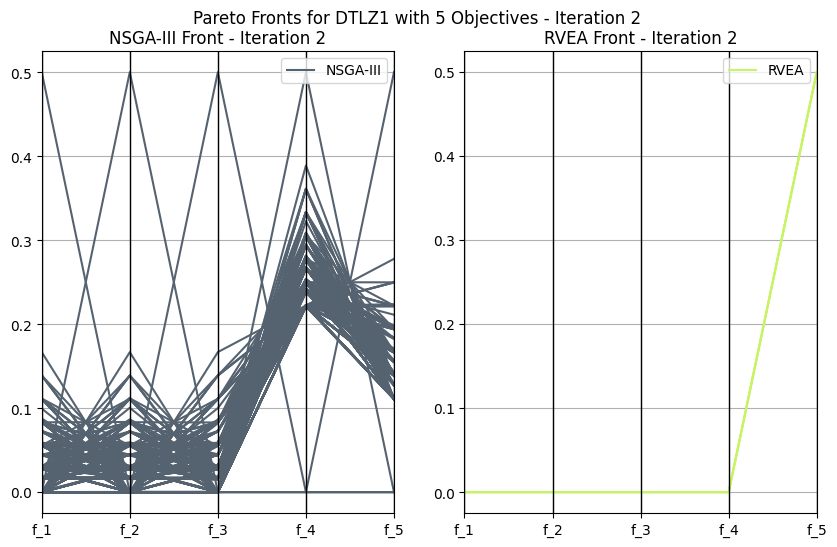

<Figure size 640x480 with 0 Axes>

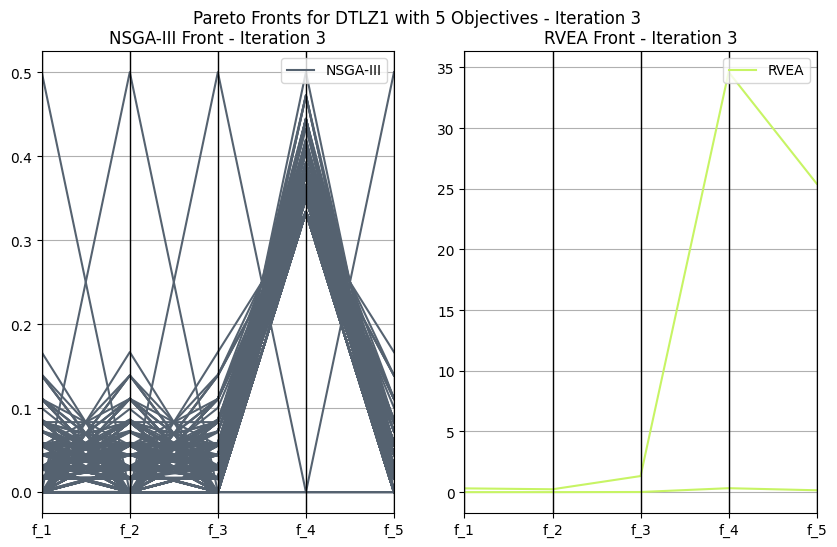

<Figure size 640x480 with 0 Axes>

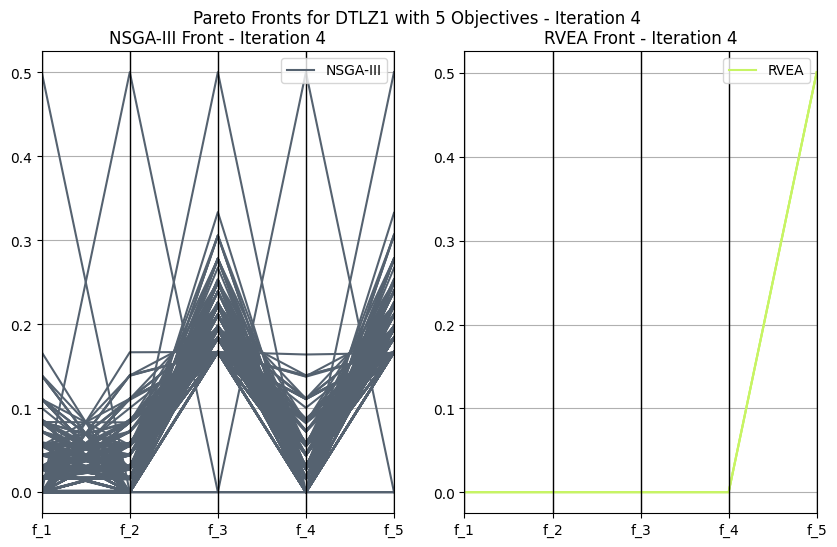

<Figure size 640x480 with 0 Axes>

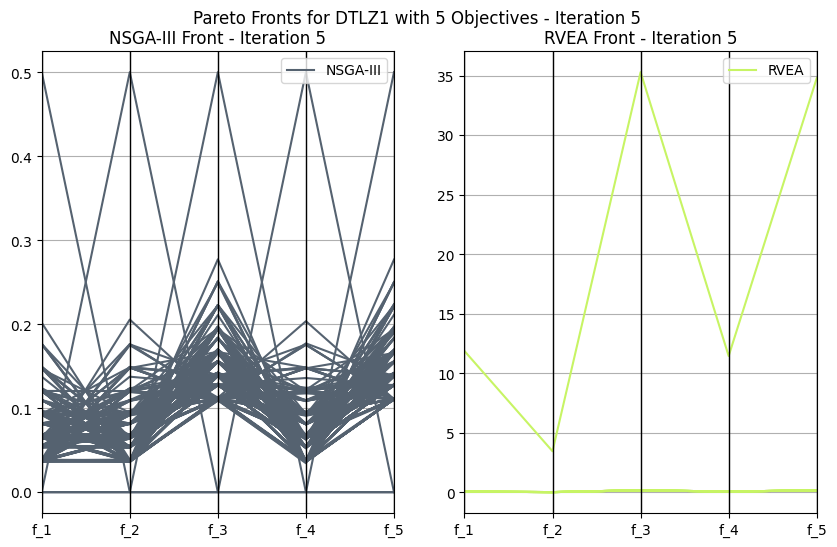

<Figure size 640x480 with 0 Axes>

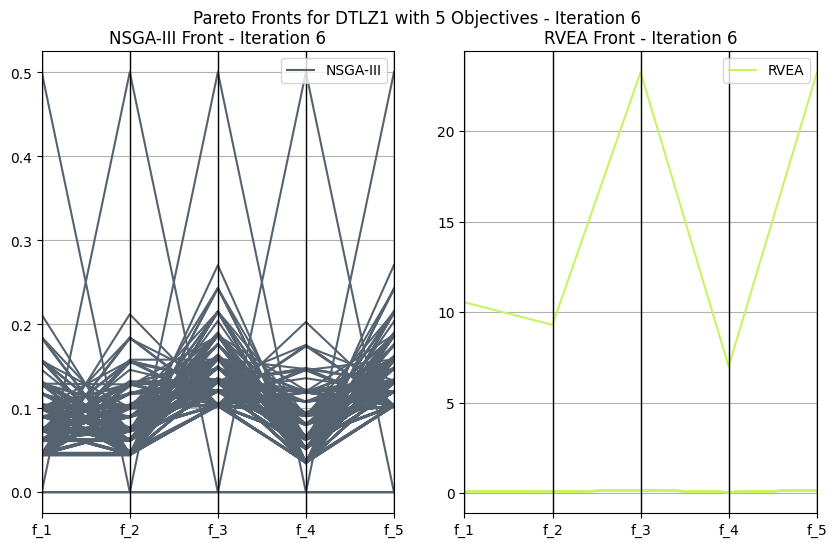

<Figure size 640x480 with 0 Axes>

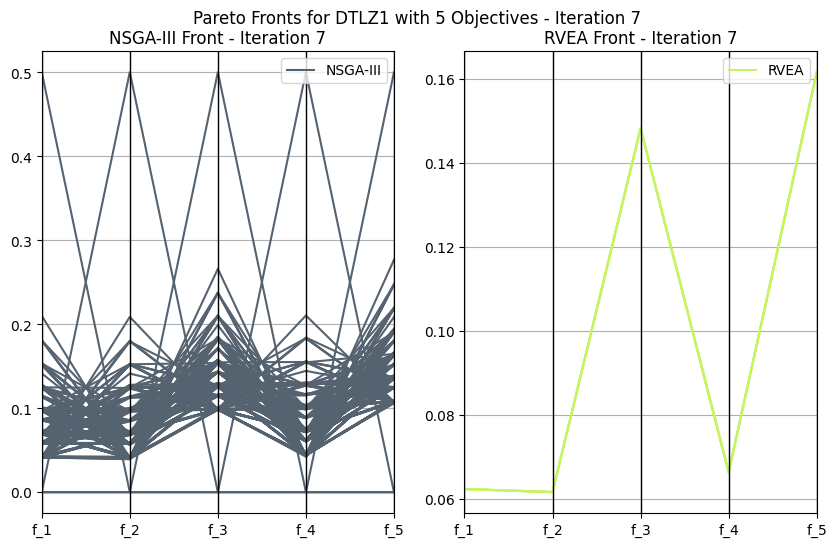

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

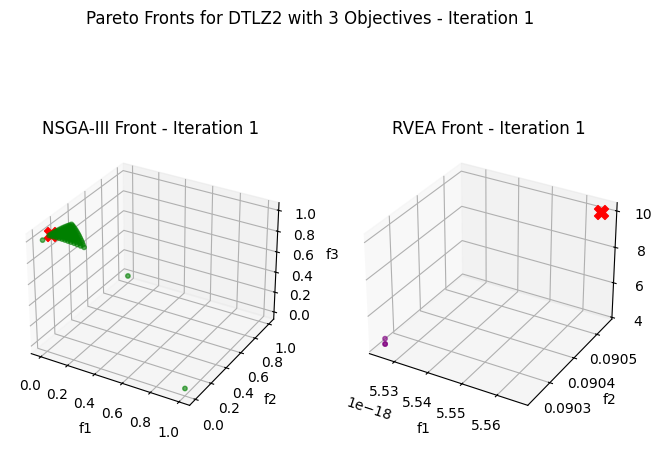

<Figure size 640x480 with 0 Axes>

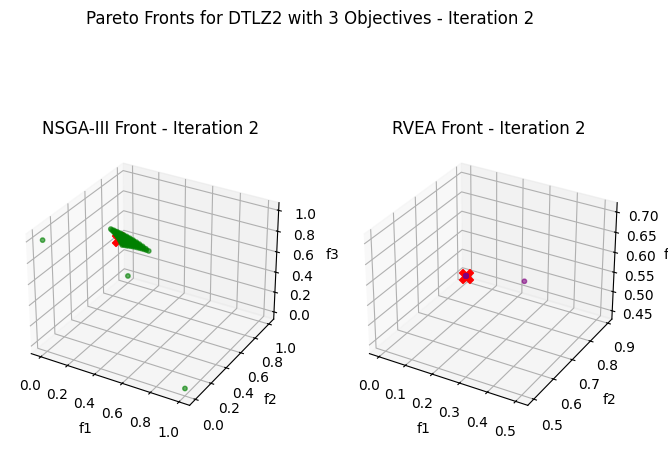

<Figure size 640x480 with 0 Axes>

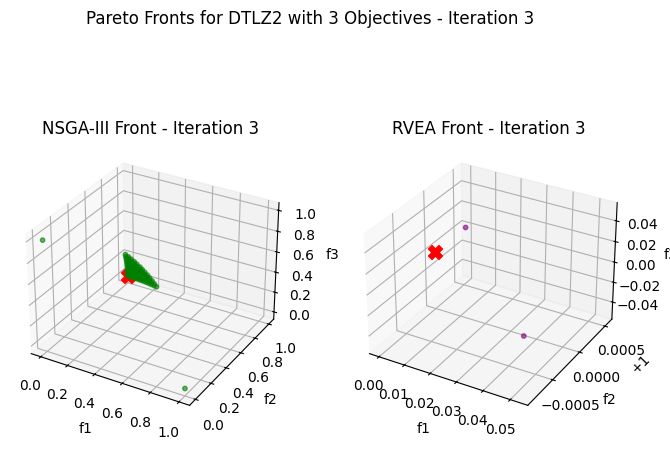

<Figure size 640x480 with 0 Axes>

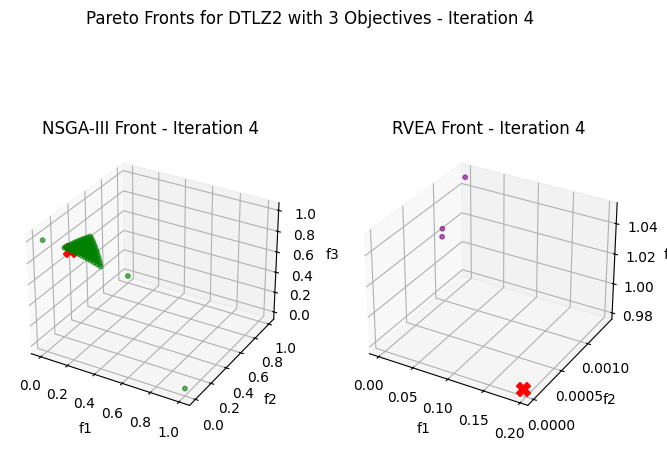

<Figure size 640x480 with 0 Axes>

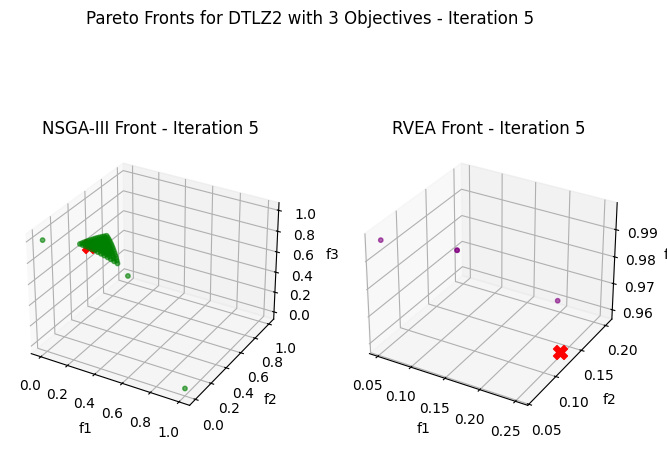

<Figure size 640x480 with 0 Axes>

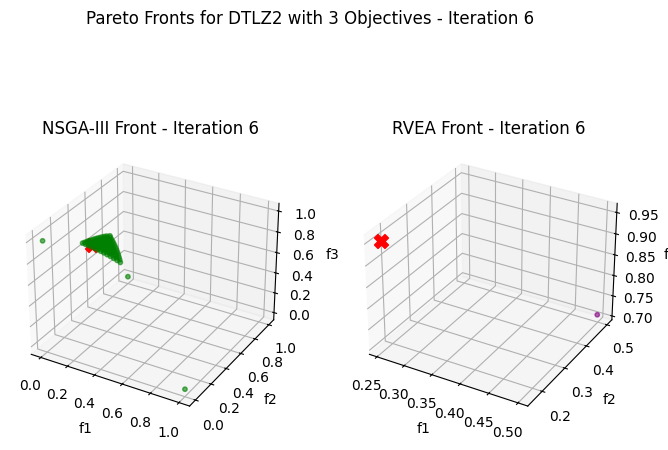

<Figure size 640x480 with 0 Axes>

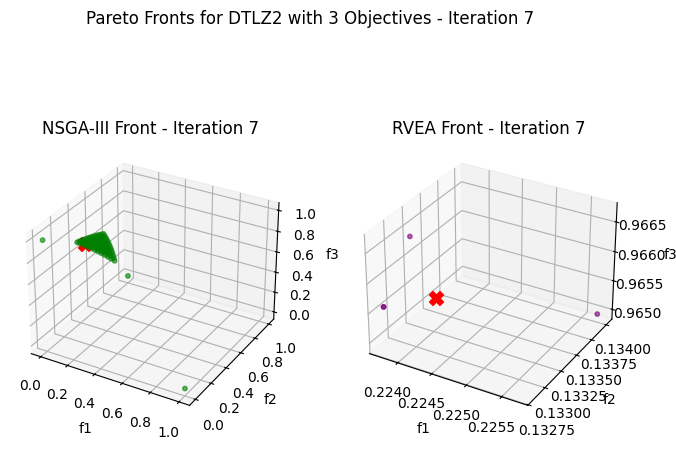

<Figure size 800x600 with 0 Axes>

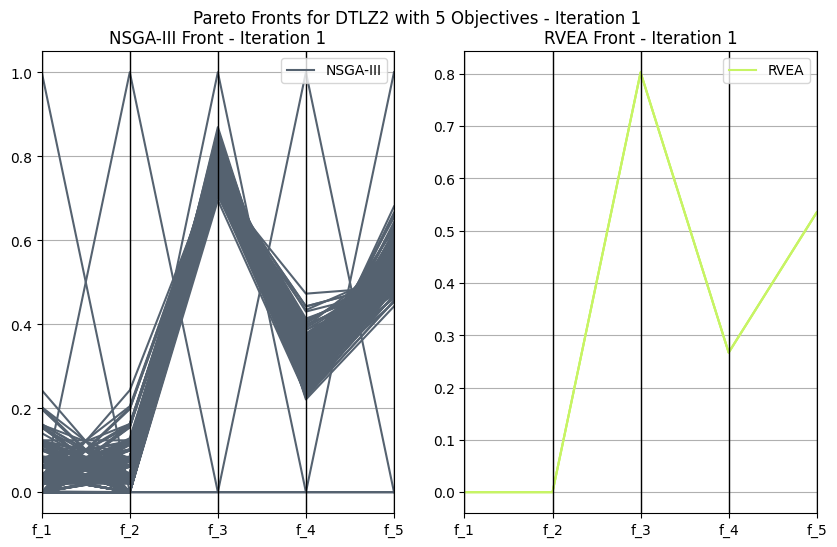

<Figure size 640x480 with 0 Axes>

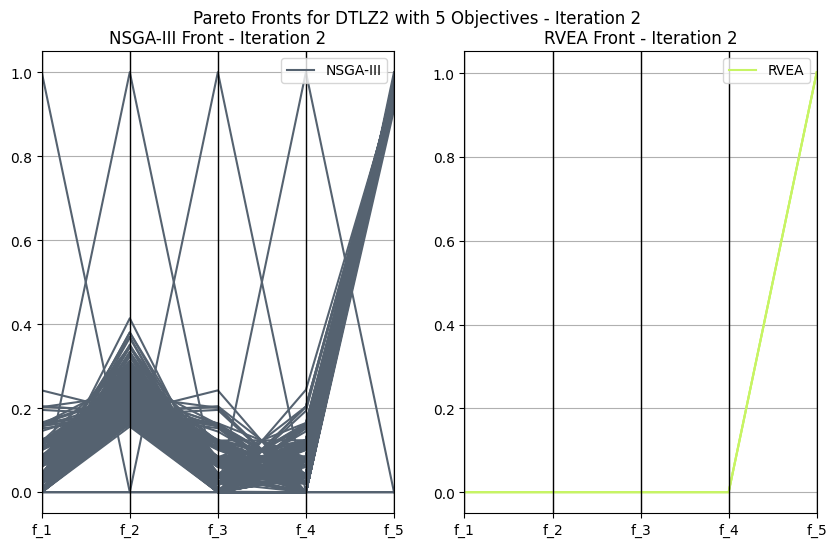

<Figure size 640x480 with 0 Axes>

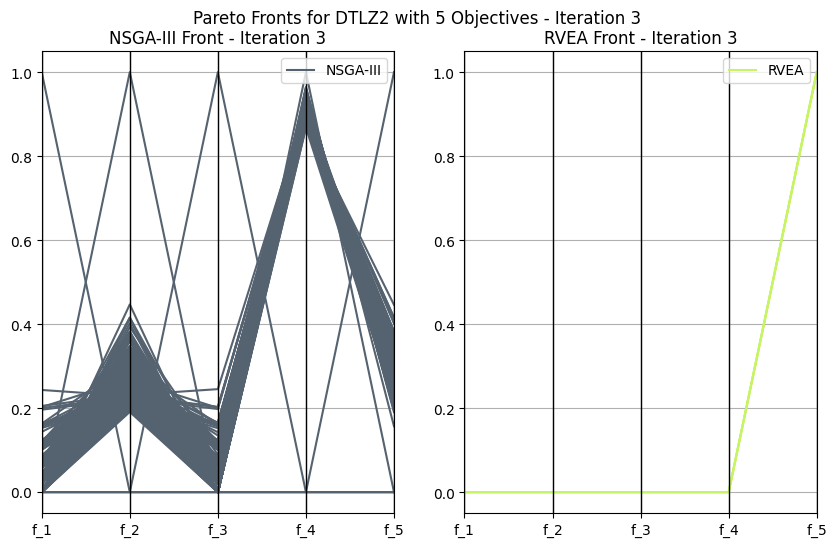

<Figure size 640x480 with 0 Axes>

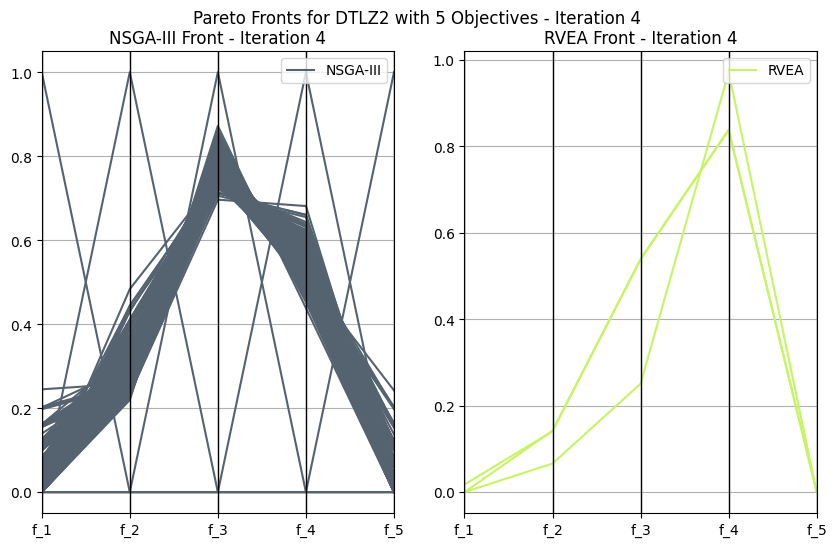

<Figure size 640x480 with 0 Axes>

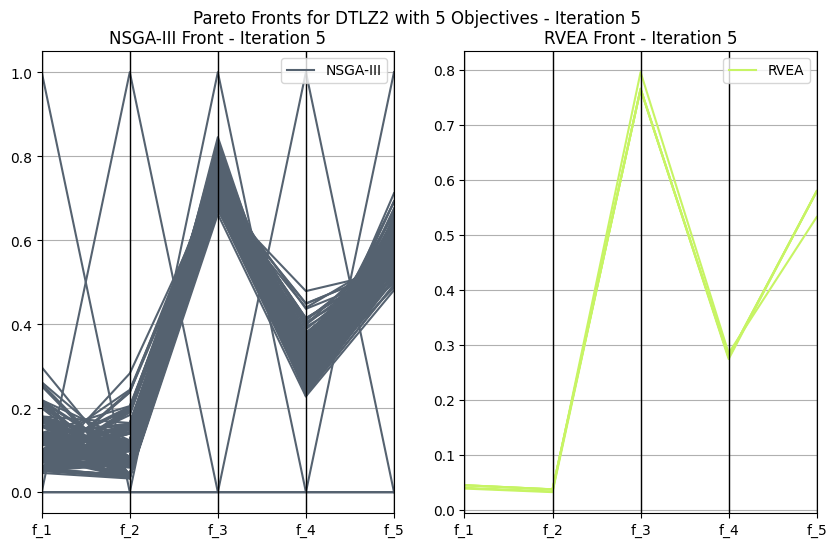

<Figure size 640x480 with 0 Axes>

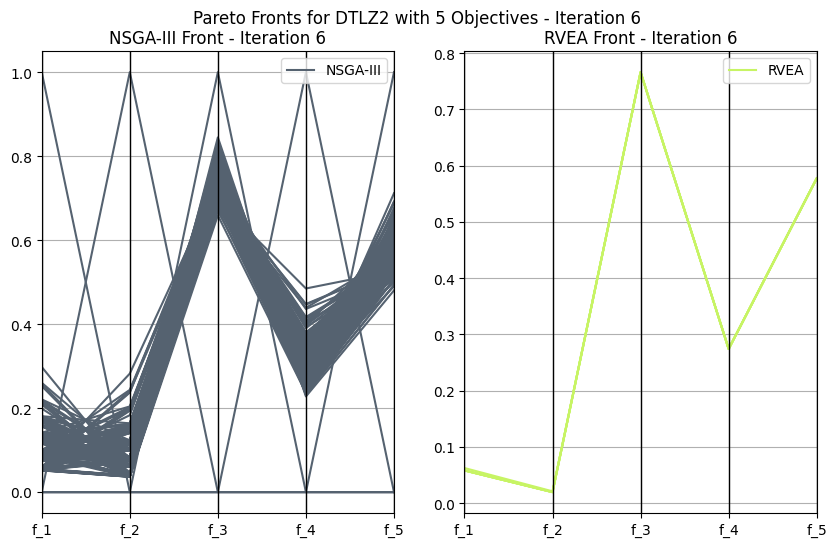

<Figure size 640x480 with 0 Axes>

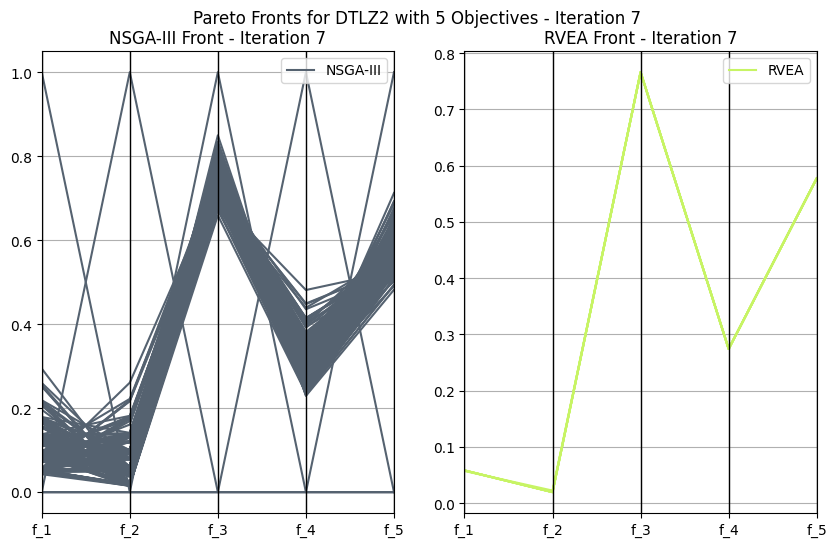

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

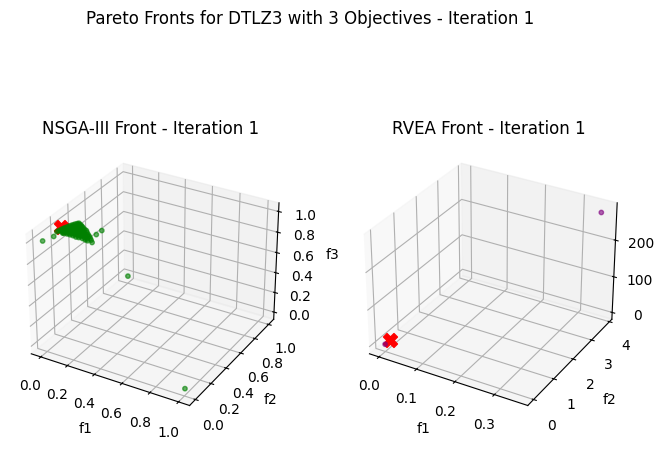

<Figure size 640x480 with 0 Axes>

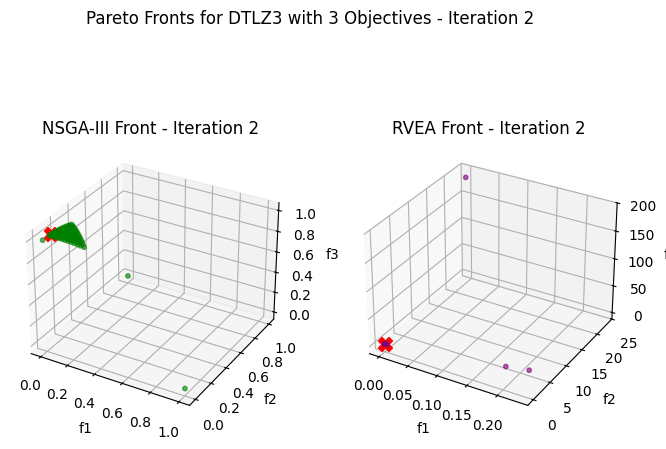

<Figure size 640x480 with 0 Axes>

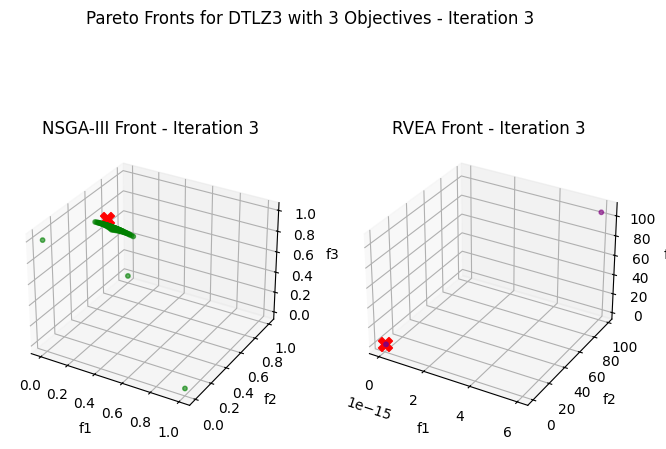

<Figure size 640x480 with 0 Axes>

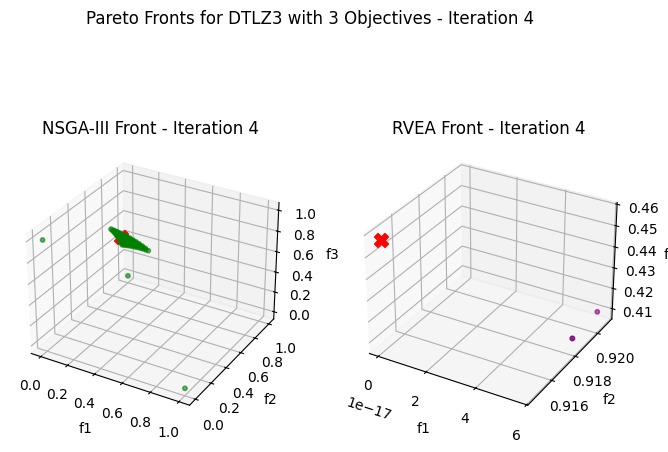

<Figure size 640x480 with 0 Axes>

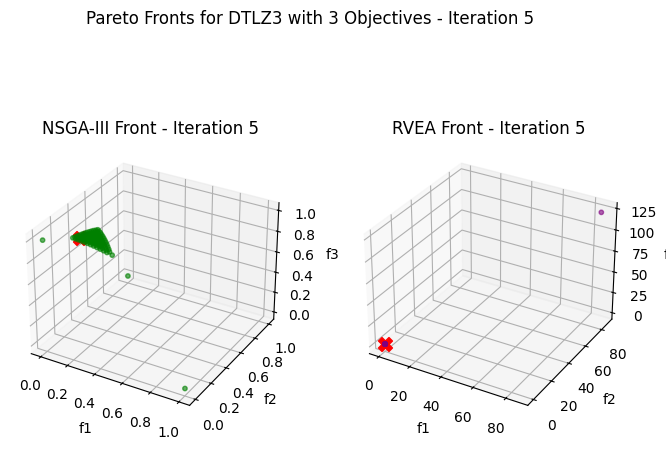

<Figure size 640x480 with 0 Axes>

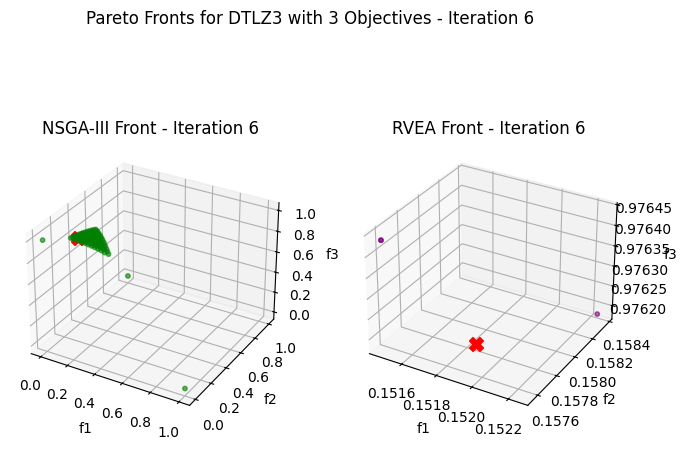

<Figure size 640x480 with 0 Axes>

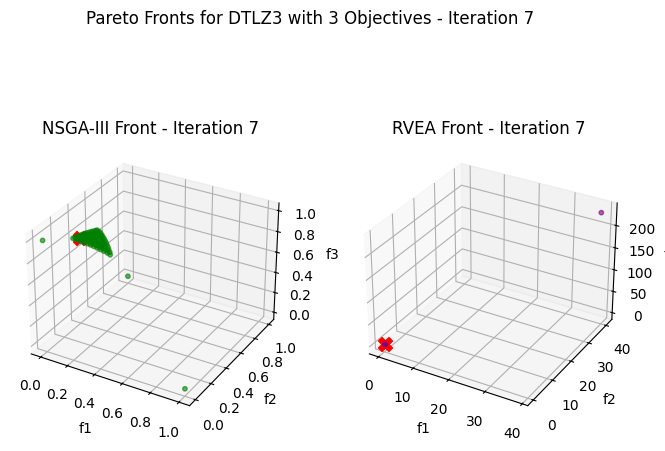

<Figure size 800x600 with 0 Axes>

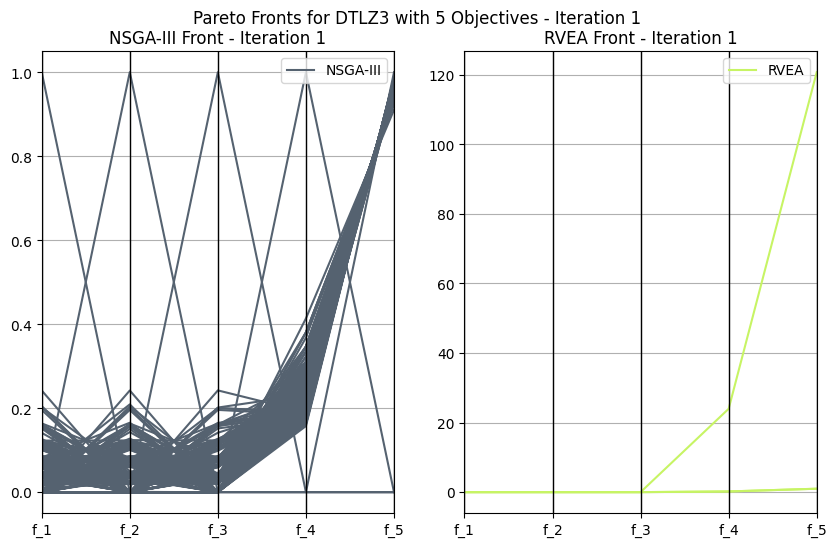

<Figure size 640x480 with 0 Axes>

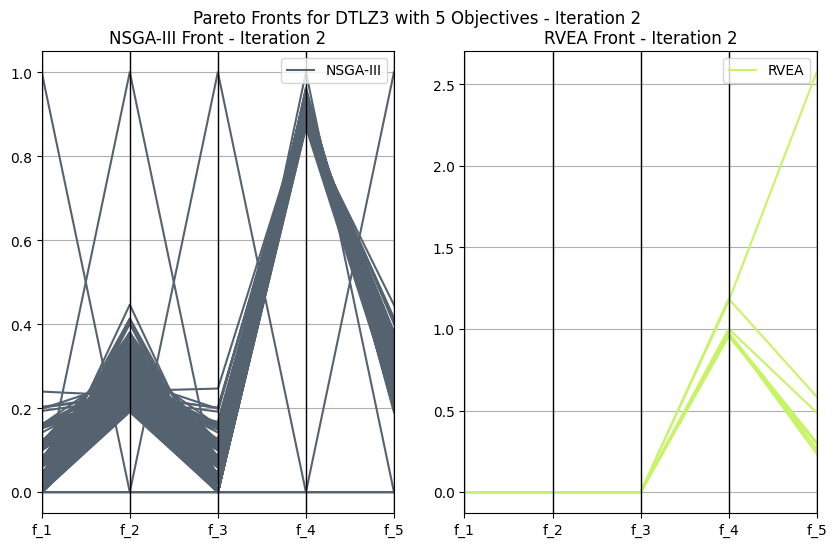

<Figure size 640x480 with 0 Axes>

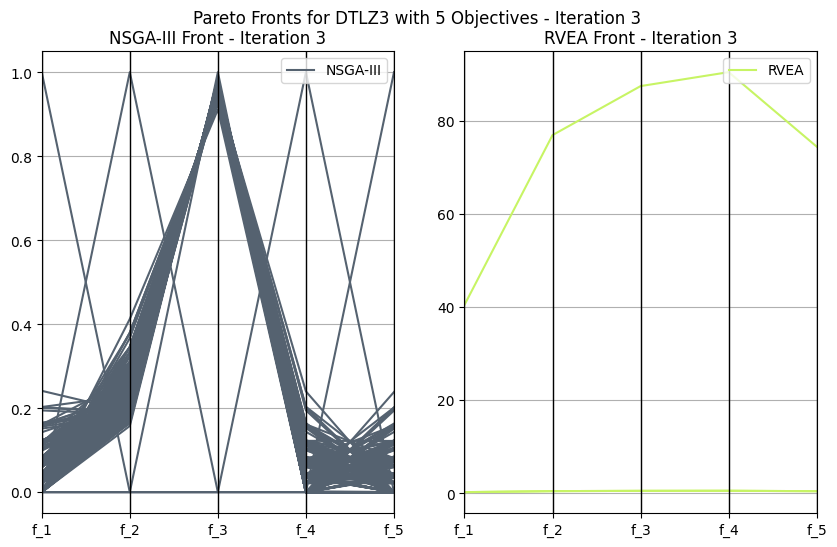

<Figure size 640x480 with 0 Axes>

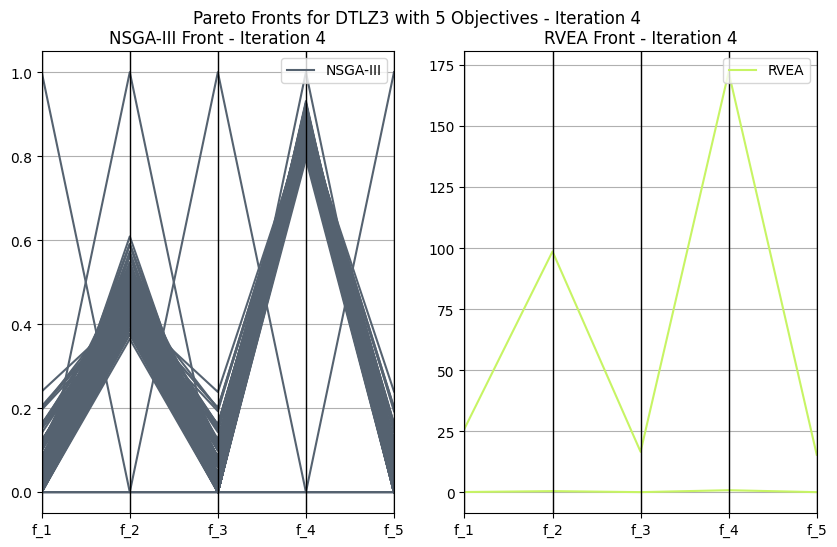

<Figure size 640x480 with 0 Axes>

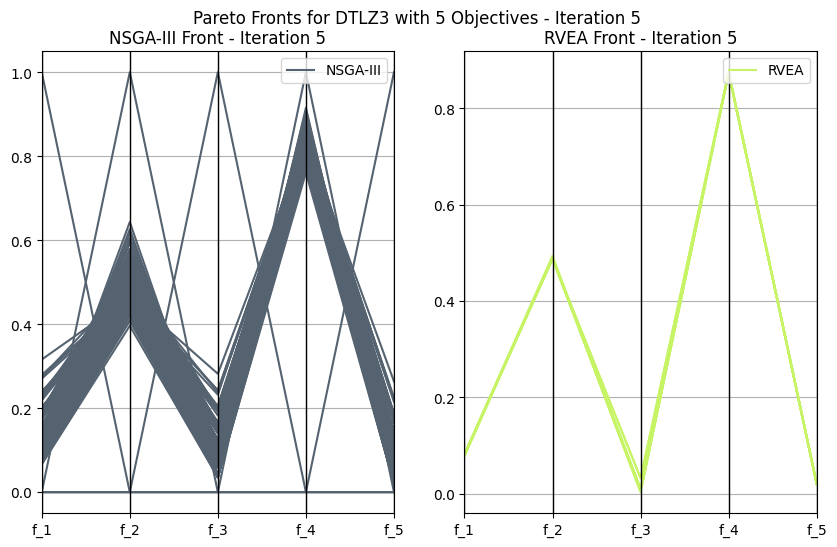

<Figure size 640x480 with 0 Axes>

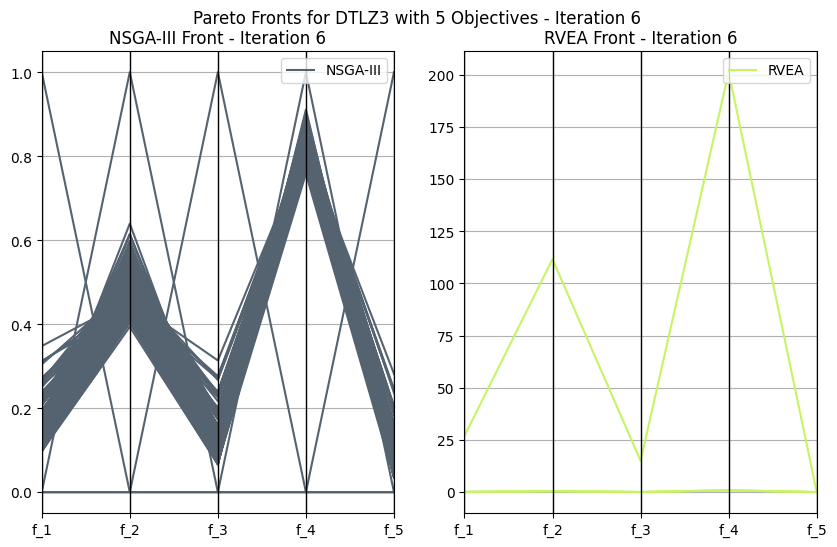

<Figure size 640x480 with 0 Axes>

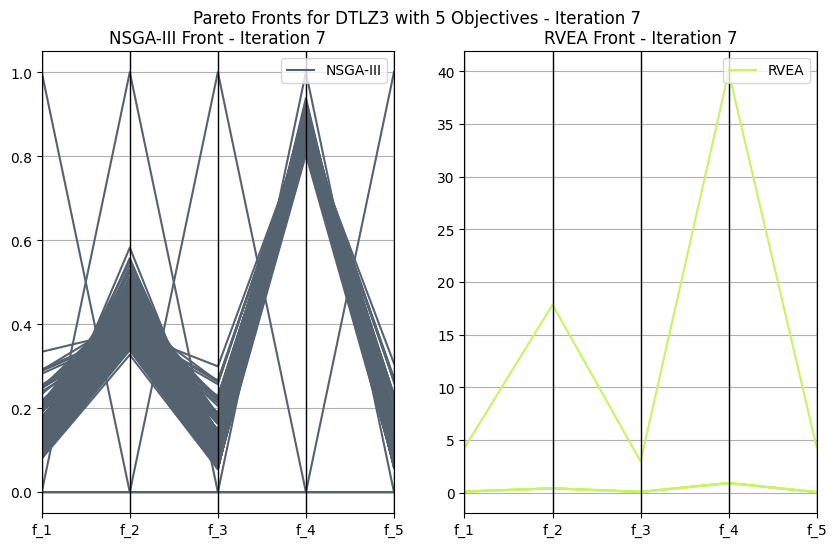

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

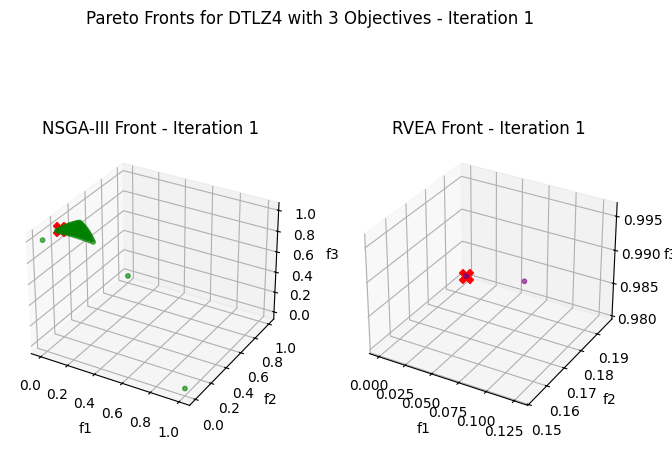

<Figure size 640x480 with 0 Axes>

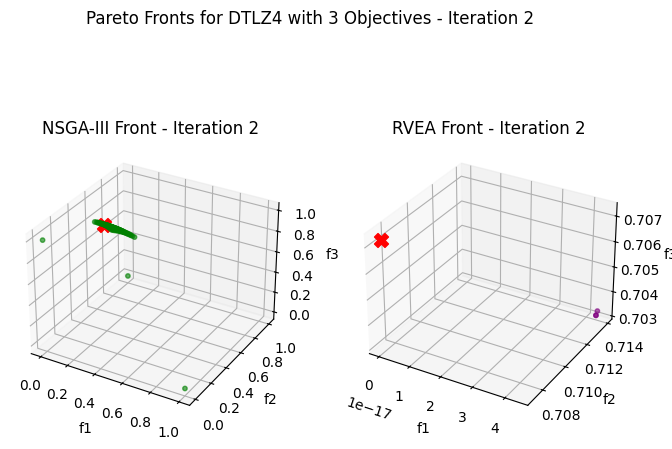

<Figure size 640x480 with 0 Axes>

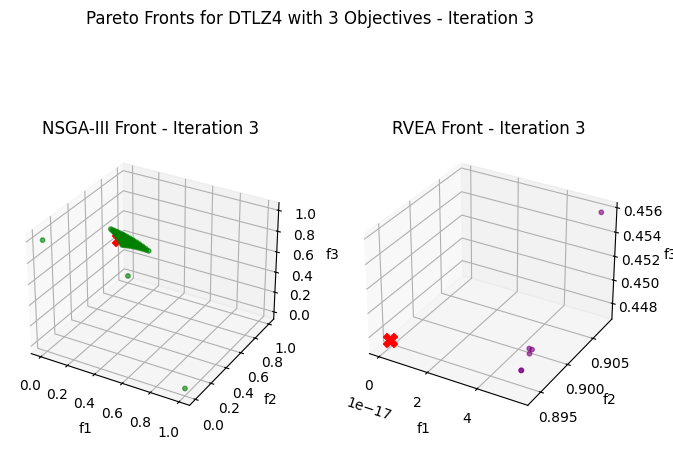

<Figure size 640x480 with 0 Axes>

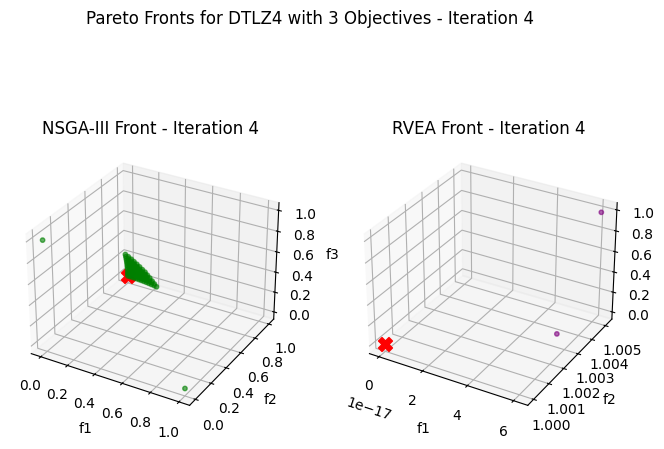

<Figure size 640x480 with 0 Axes>

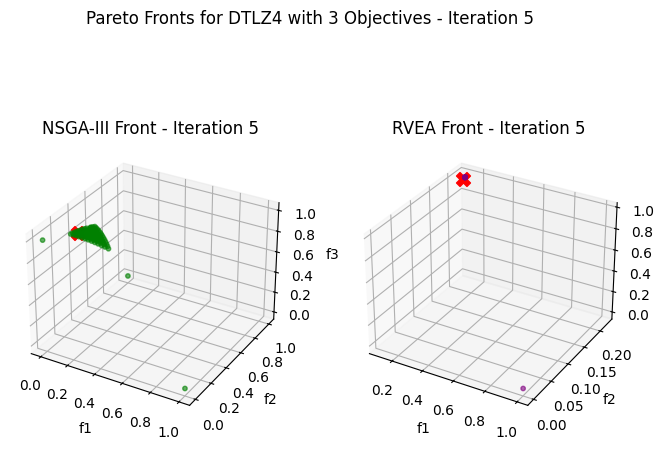

<Figure size 640x480 with 0 Axes>

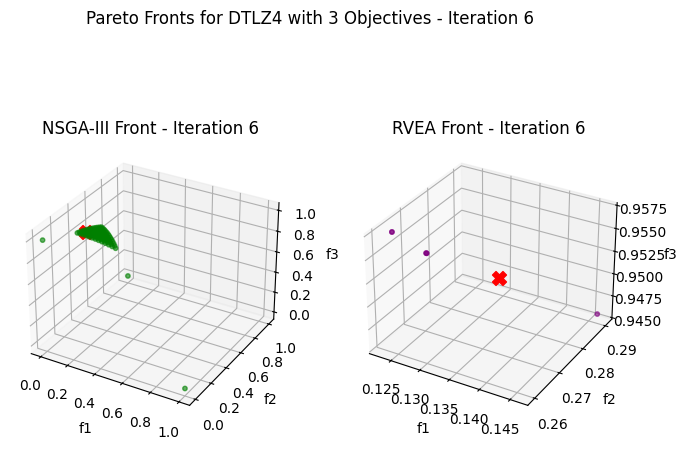

<Figure size 640x480 with 0 Axes>

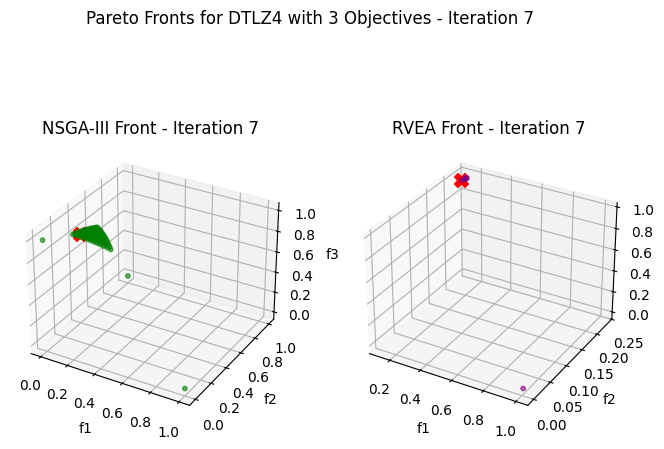

<Figure size 800x600 with 0 Axes>

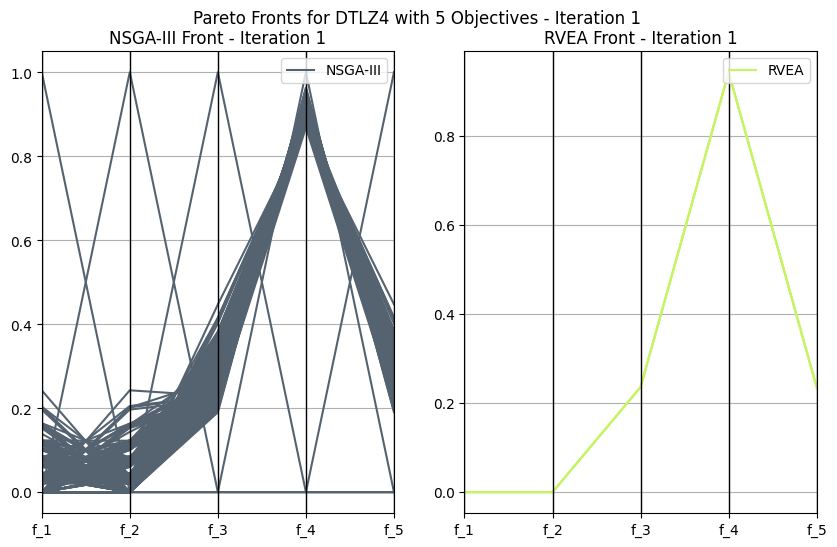

<Figure size 640x480 with 0 Axes>

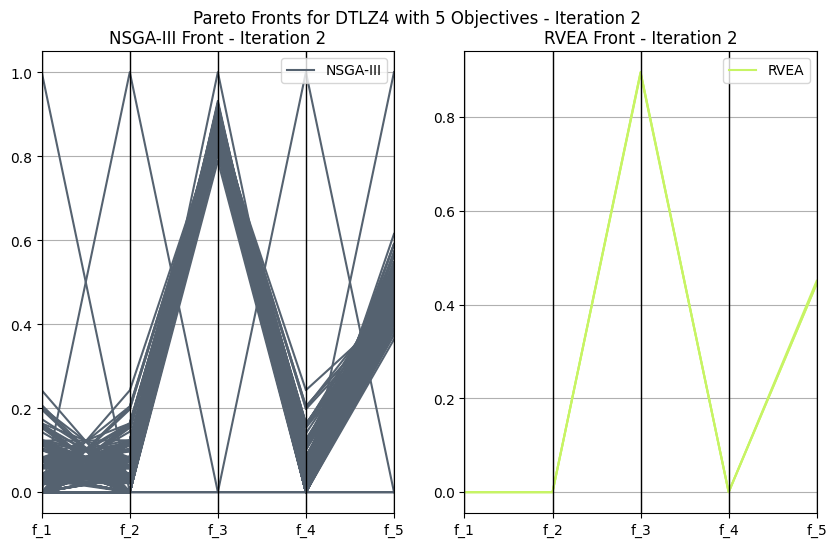

<Figure size 640x480 with 0 Axes>

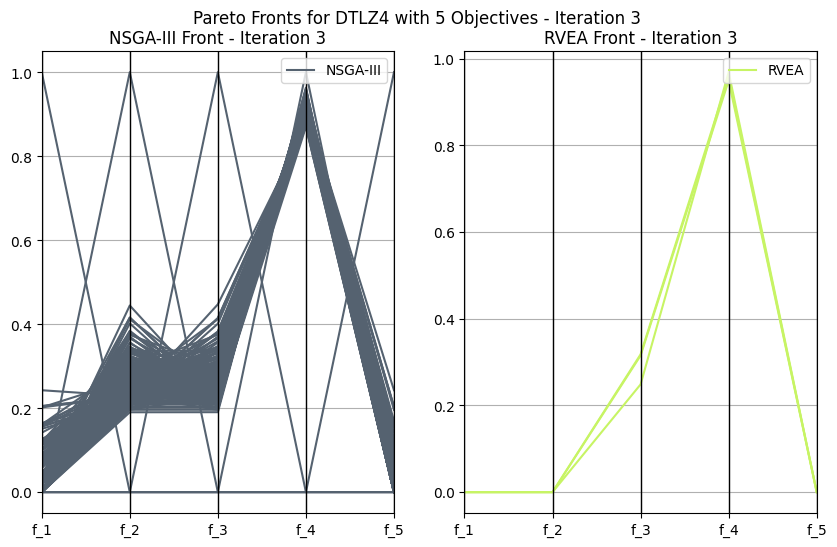

<Figure size 640x480 with 0 Axes>

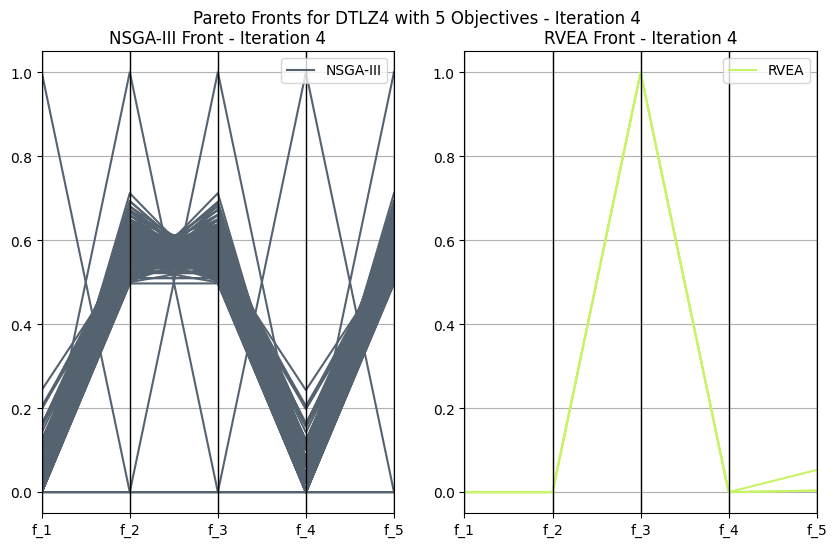

<Figure size 640x480 with 0 Axes>

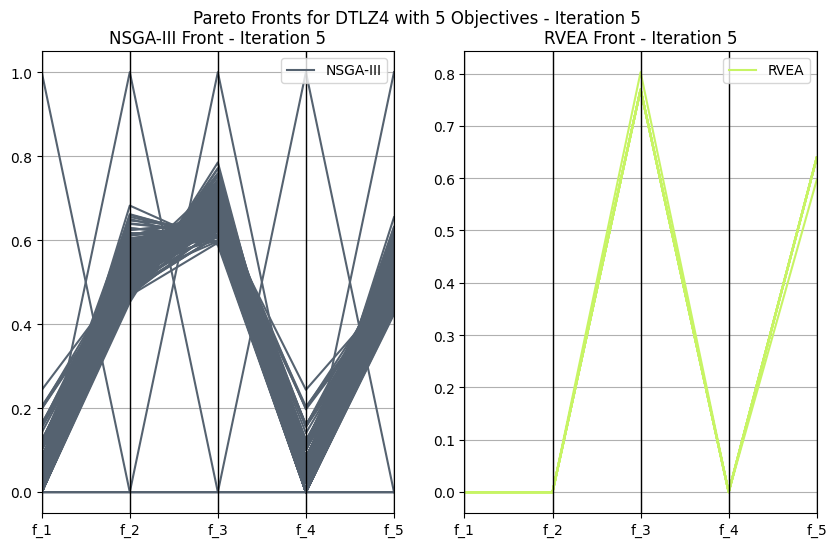

<Figure size 640x480 with 0 Axes>

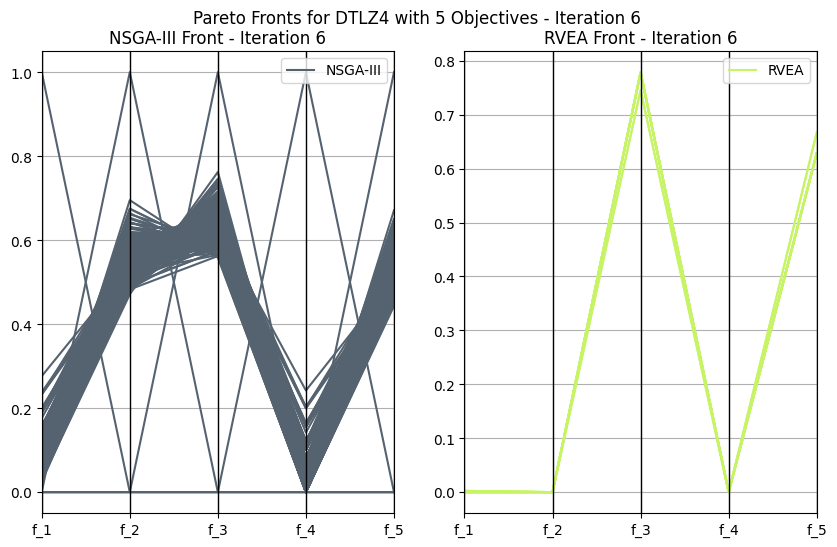

<Figure size 640x480 with 0 Axes>

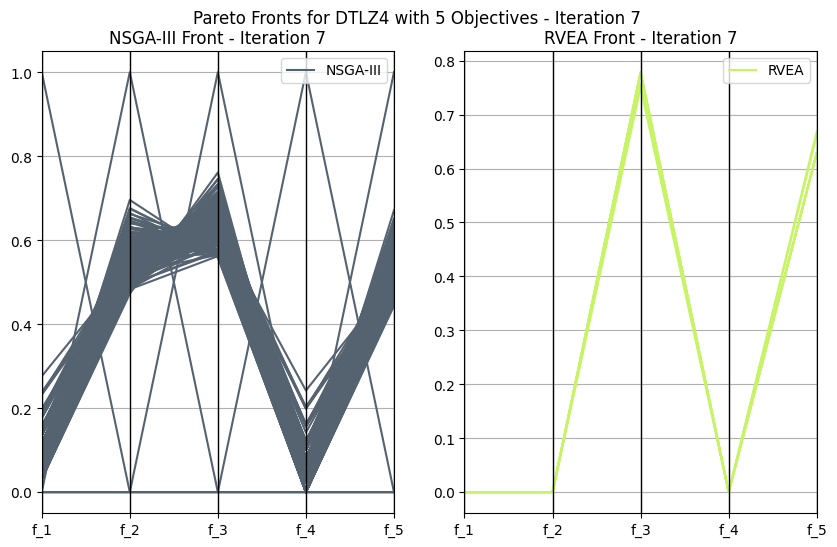

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

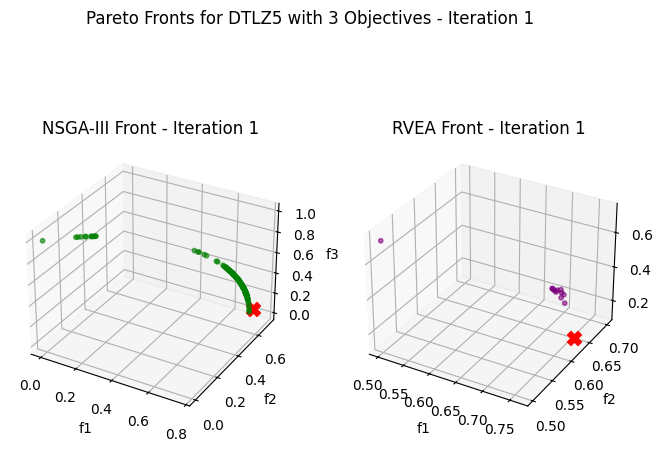

<Figure size 640x480 with 0 Axes>

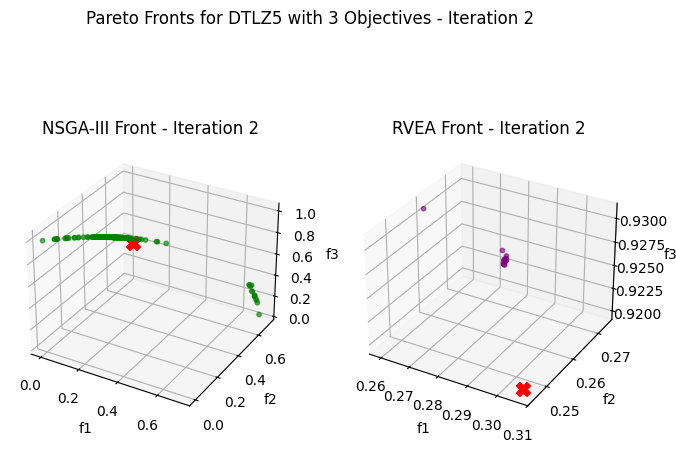

<Figure size 640x480 with 0 Axes>

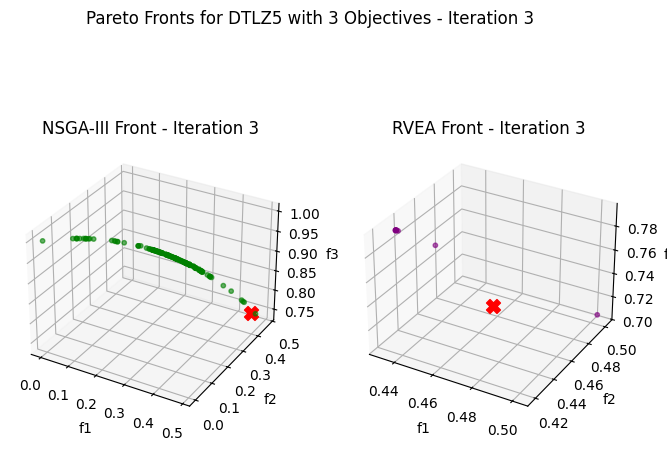

<Figure size 640x480 with 0 Axes>

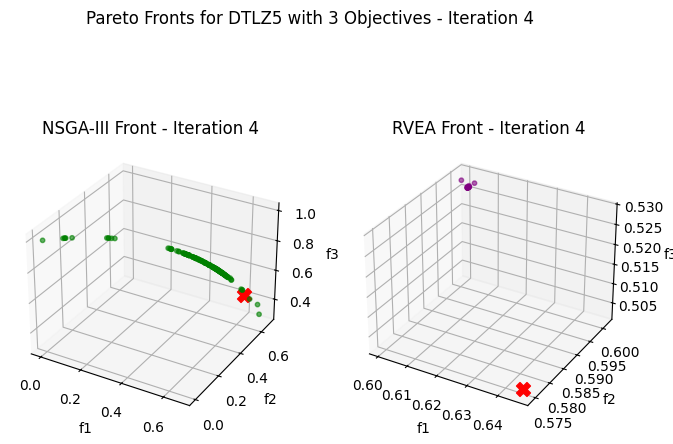

<Figure size 640x480 with 0 Axes>

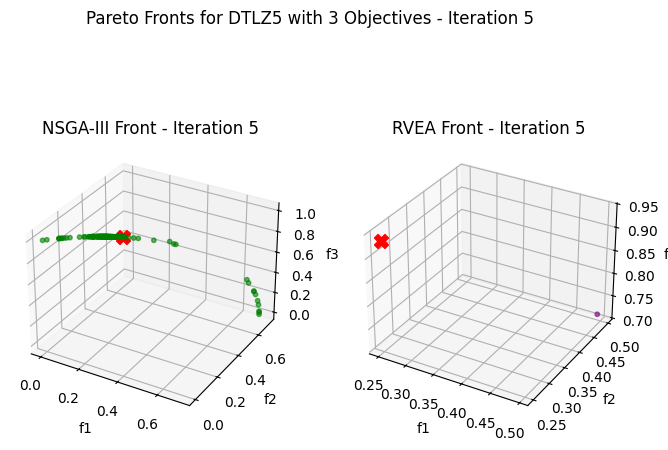

<Figure size 640x480 with 0 Axes>

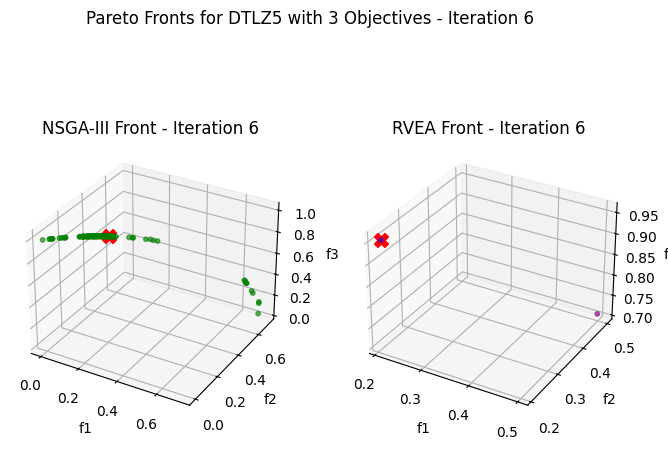

<Figure size 640x480 with 0 Axes>

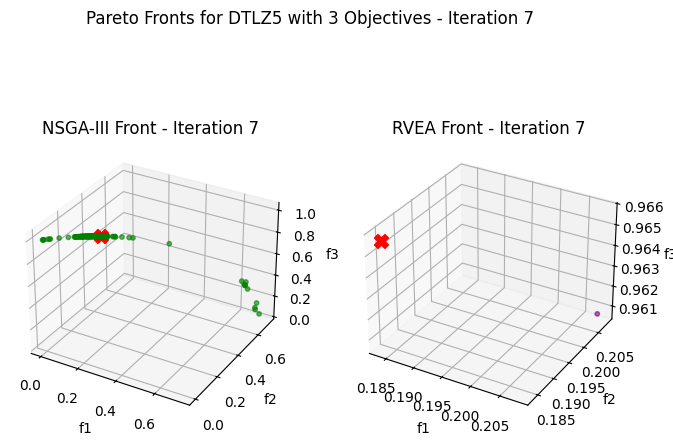

<Figure size 800x600 with 0 Axes>

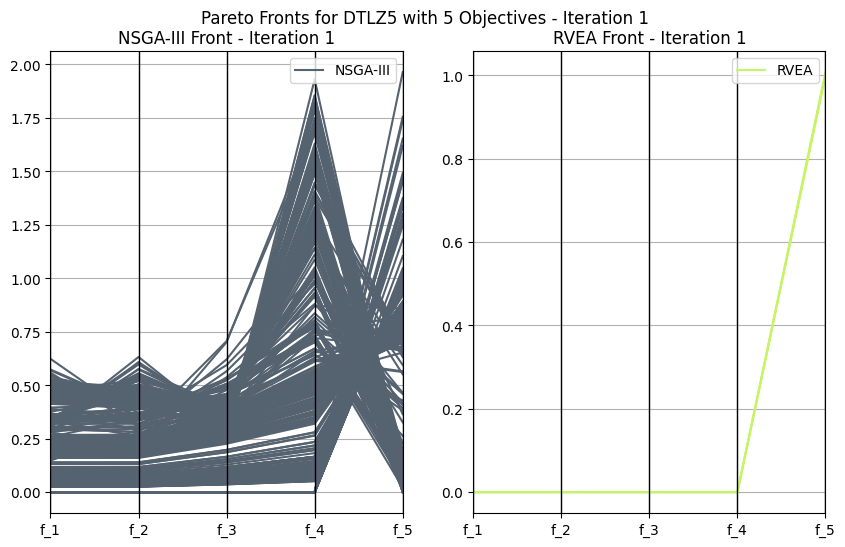

<Figure size 640x480 with 0 Axes>

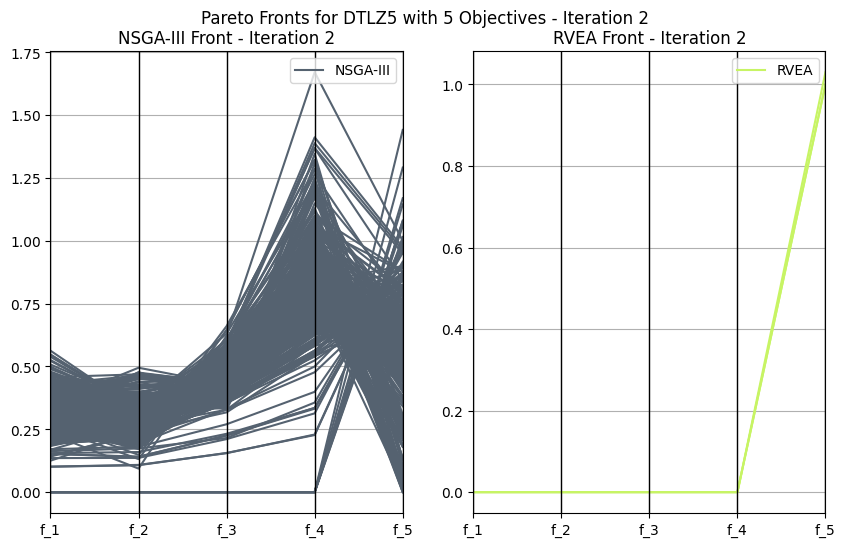

<Figure size 640x480 with 0 Axes>

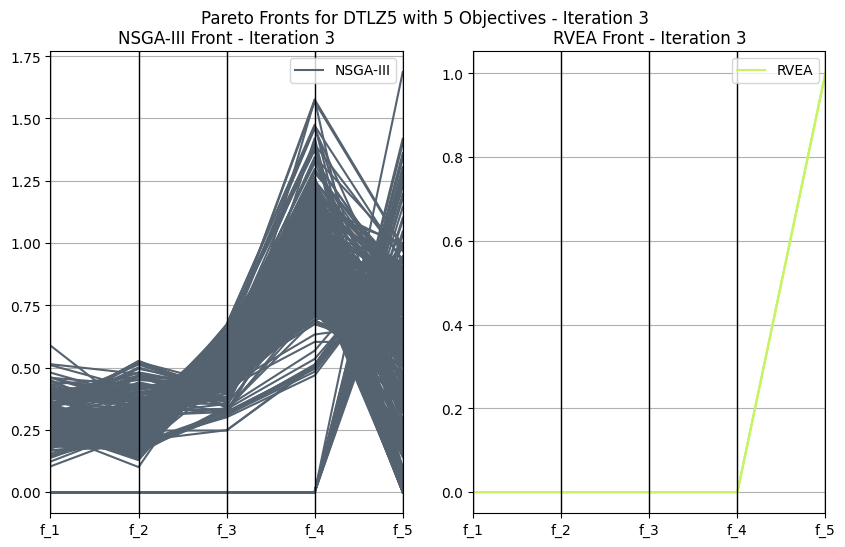

<Figure size 640x480 with 0 Axes>

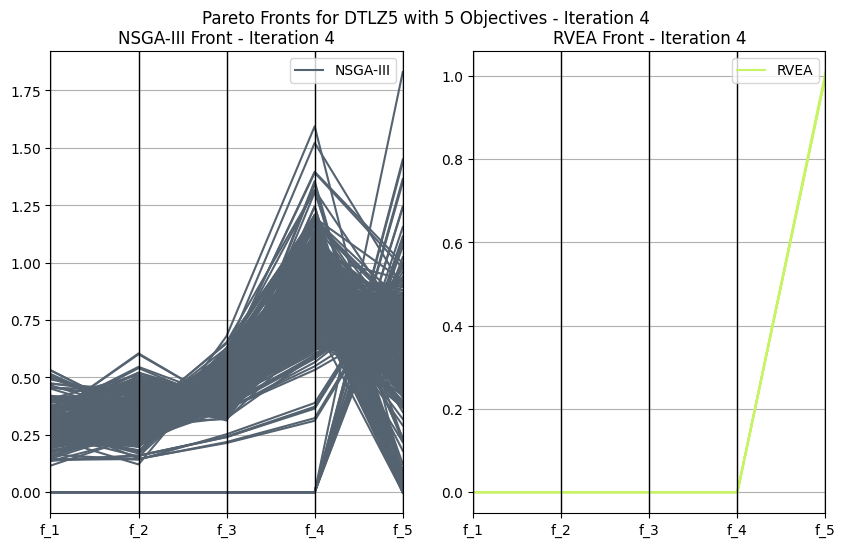

<Figure size 640x480 with 0 Axes>

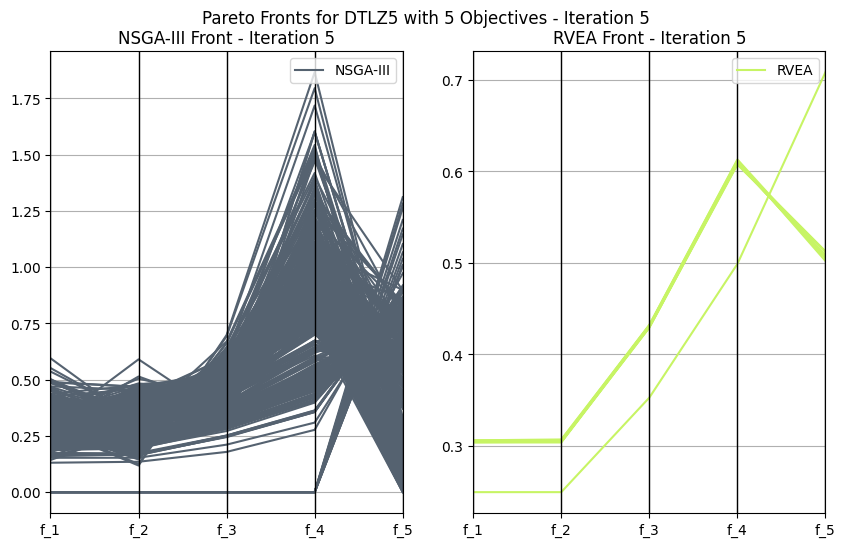

<Figure size 640x480 with 0 Axes>

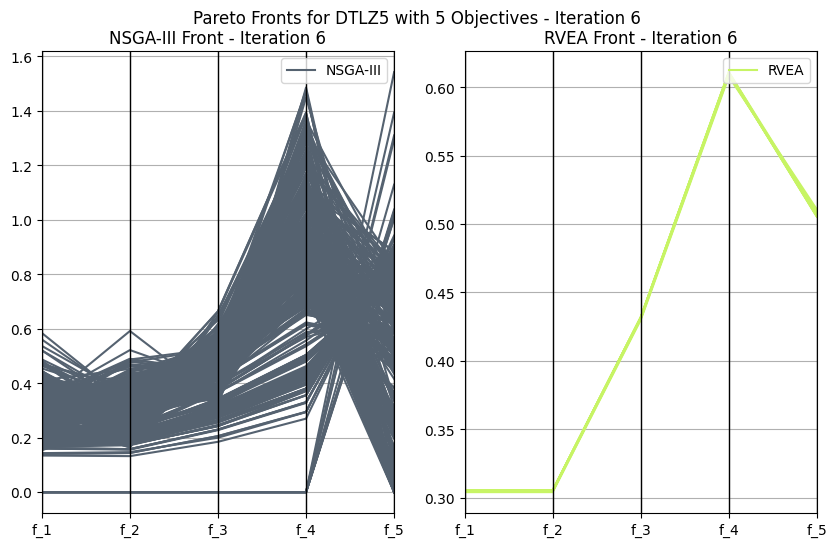

<Figure size 640x480 with 0 Axes>

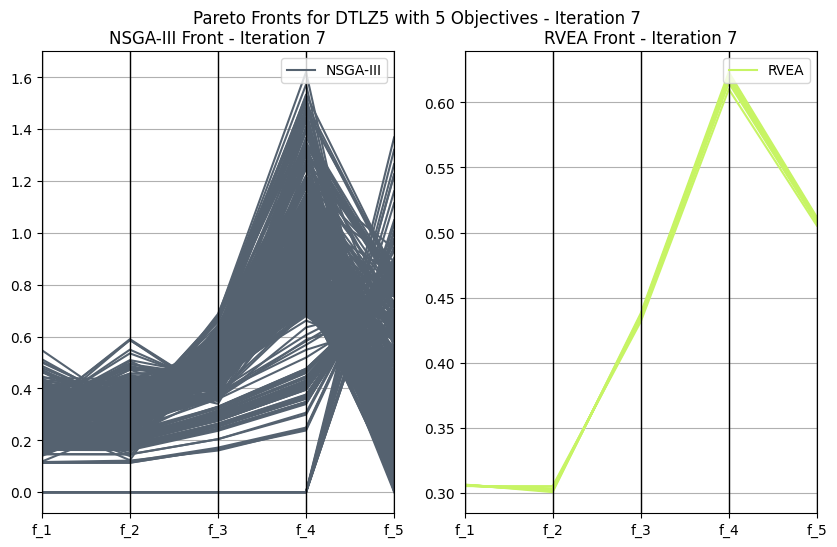

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

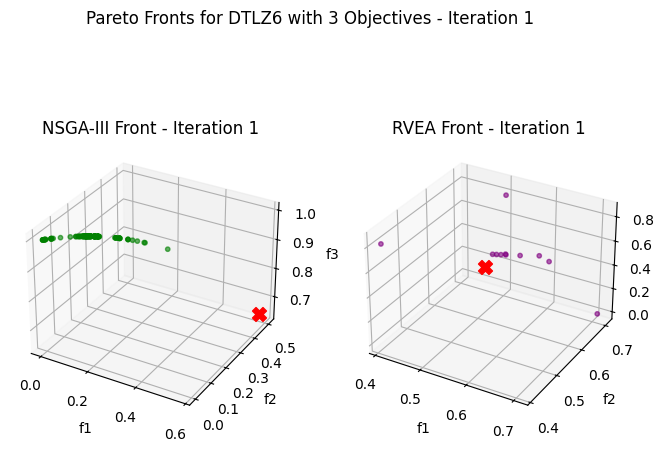

<Figure size 640x480 with 0 Axes>

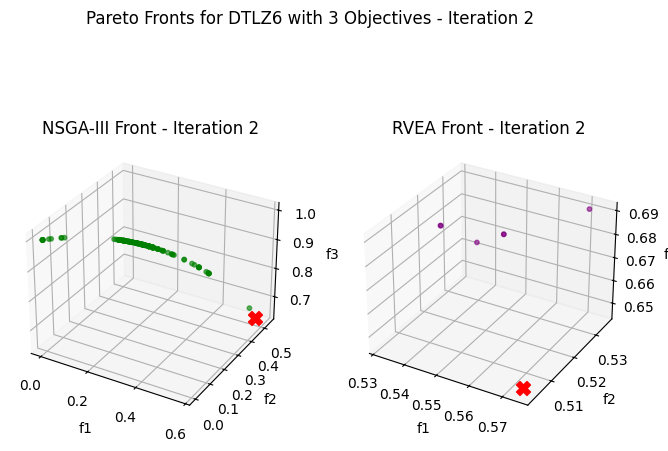

<Figure size 640x480 with 0 Axes>

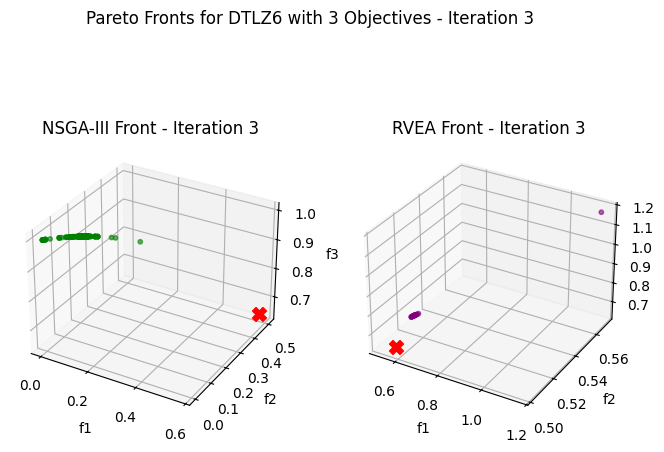

<Figure size 640x480 with 0 Axes>

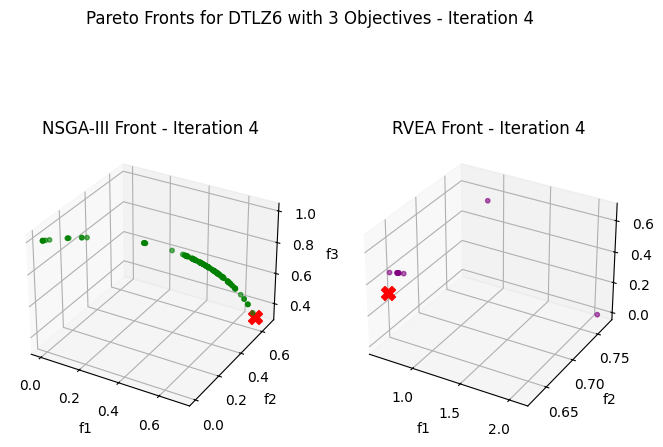

<Figure size 640x480 with 0 Axes>

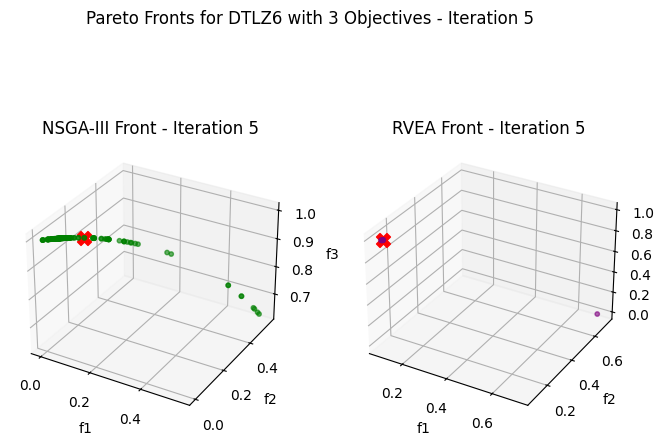

<Figure size 640x480 with 0 Axes>

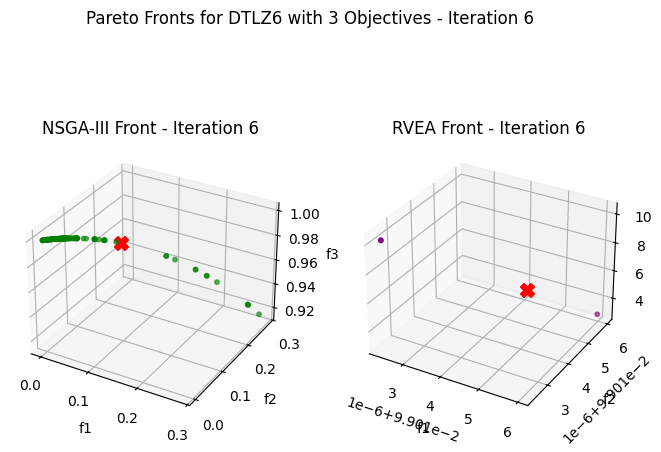

<Figure size 640x480 with 0 Axes>

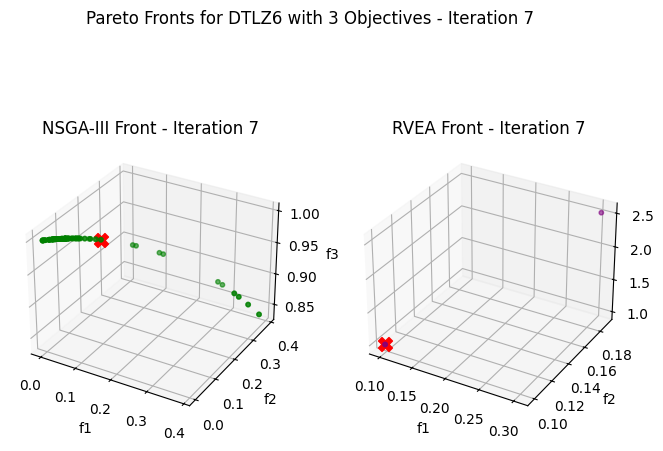

<Figure size 800x600 with 0 Axes>

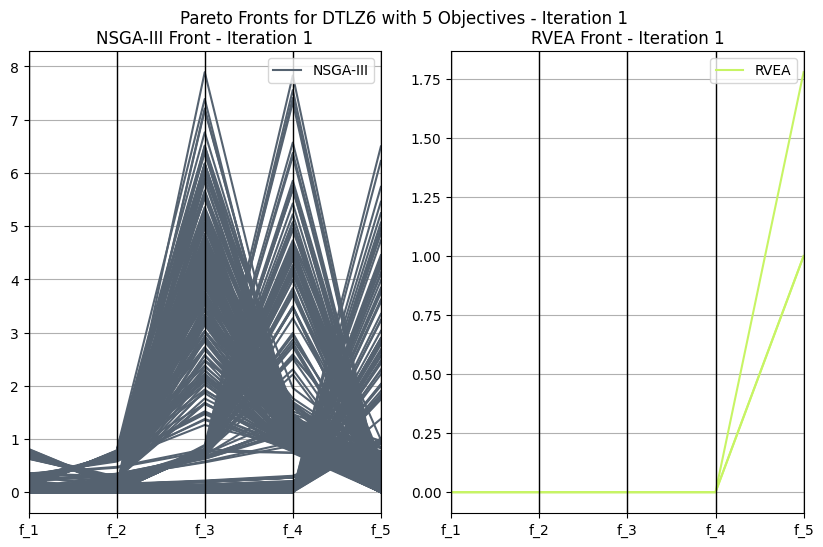

<Figure size 640x480 with 0 Axes>

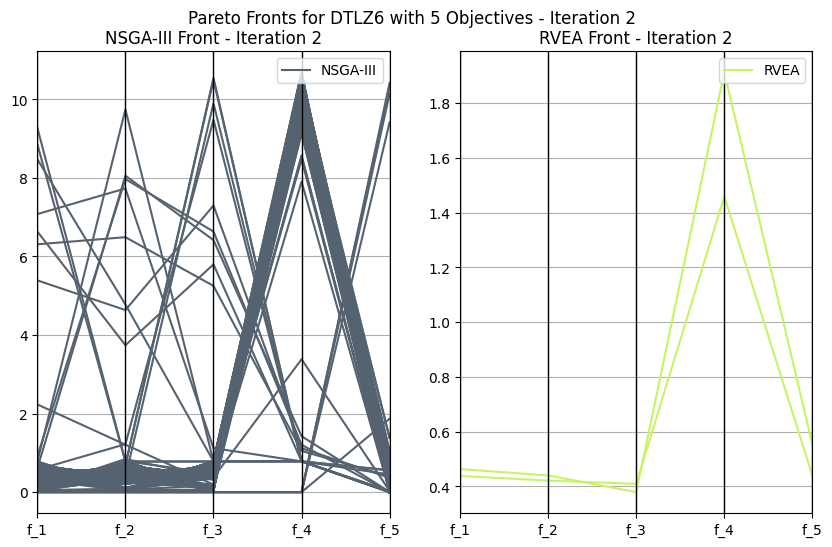

<Figure size 640x480 with 0 Axes>

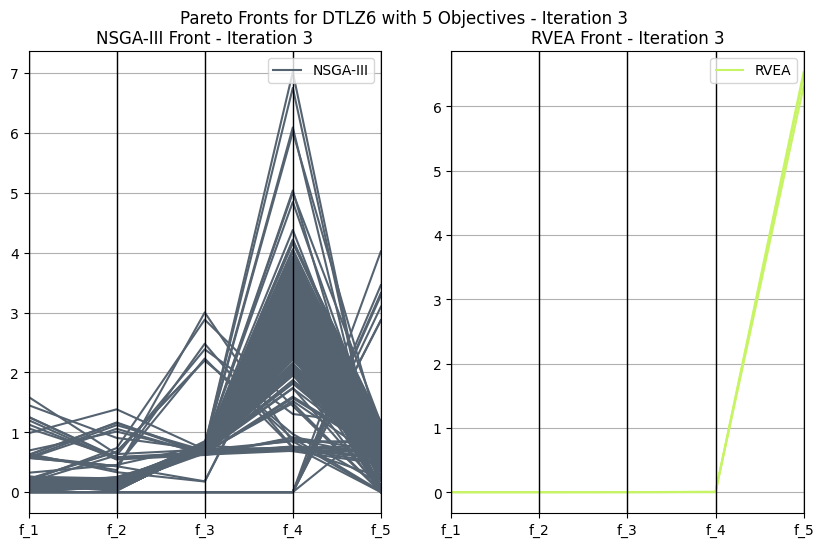

<Figure size 640x480 with 0 Axes>

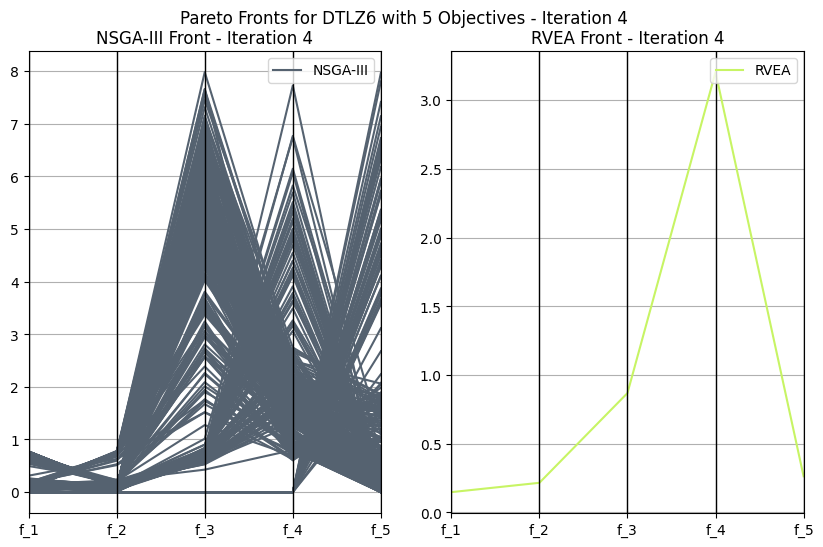

<Figure size 640x480 with 0 Axes>

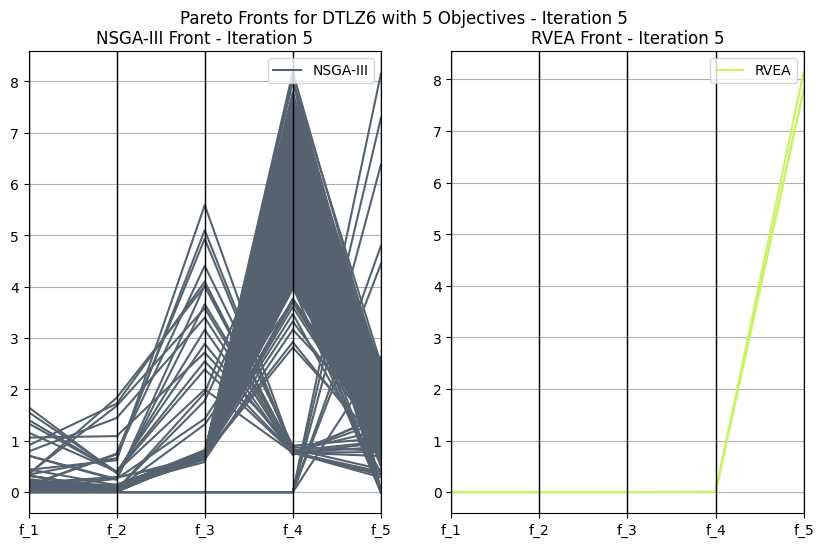

<Figure size 640x480 with 0 Axes>

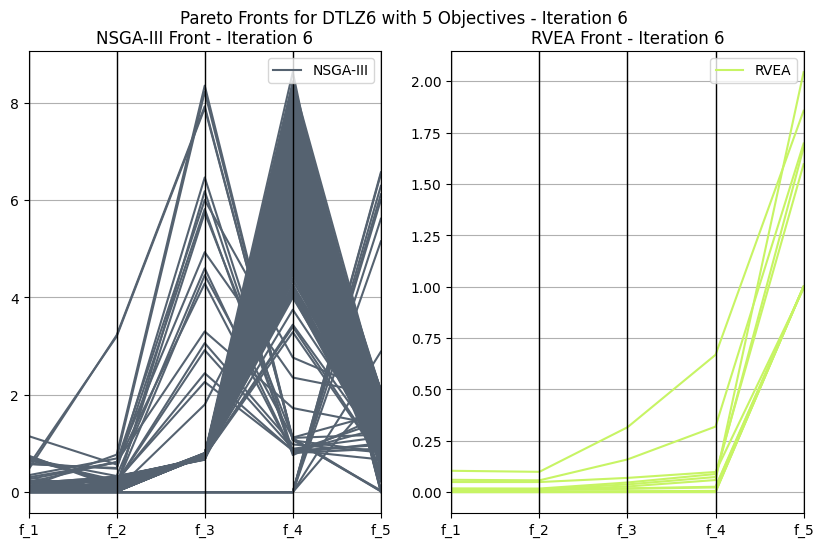

<Figure size 640x480 with 0 Axes>

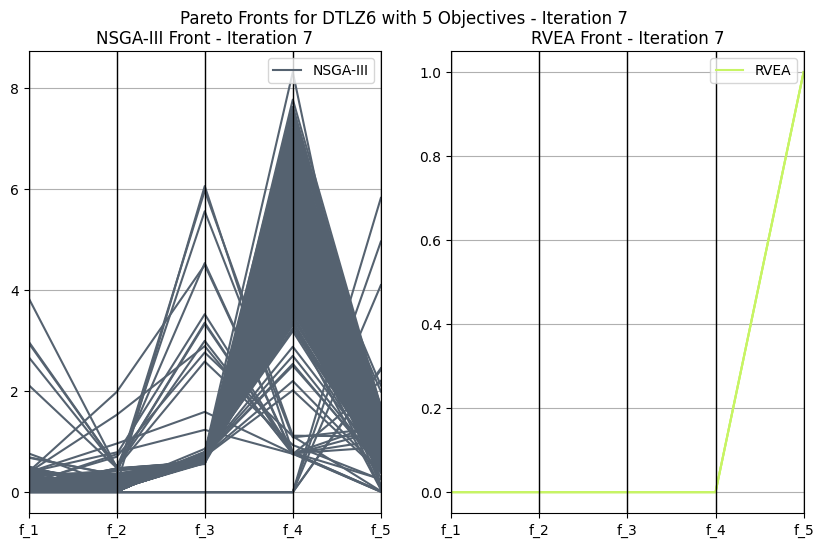

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

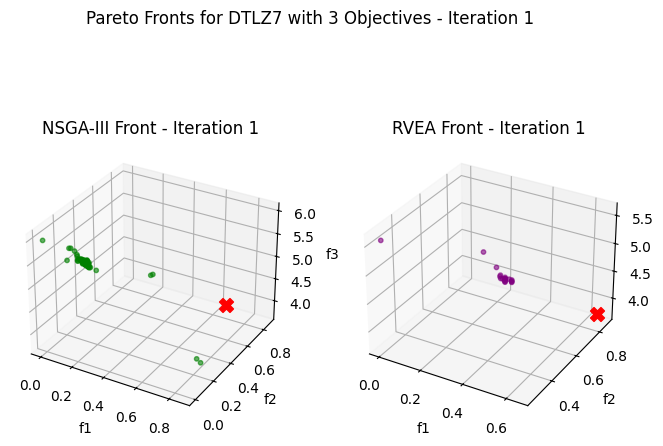

<Figure size 640x480 with 0 Axes>

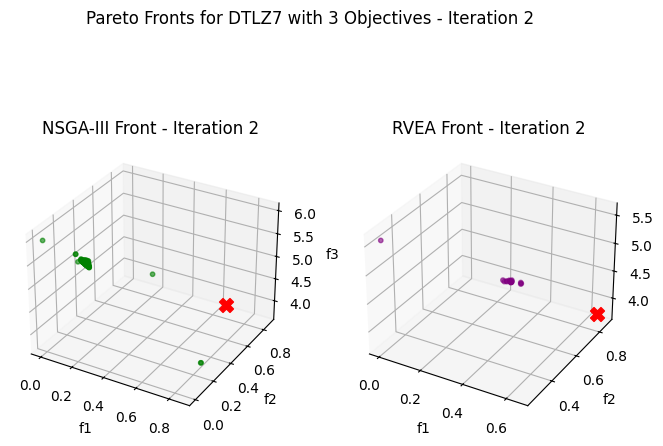

<Figure size 640x480 with 0 Axes>

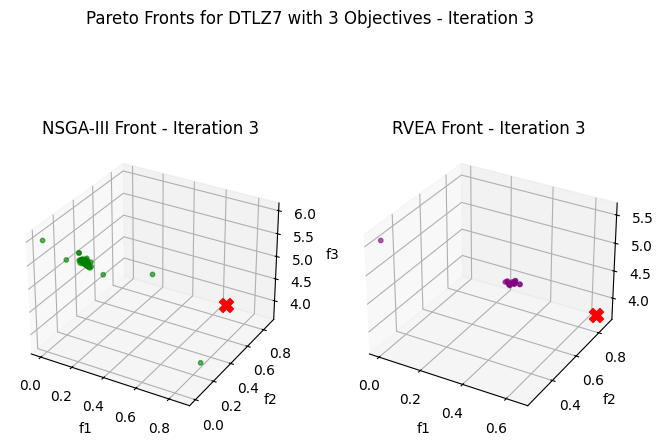

<Figure size 640x480 with 0 Axes>

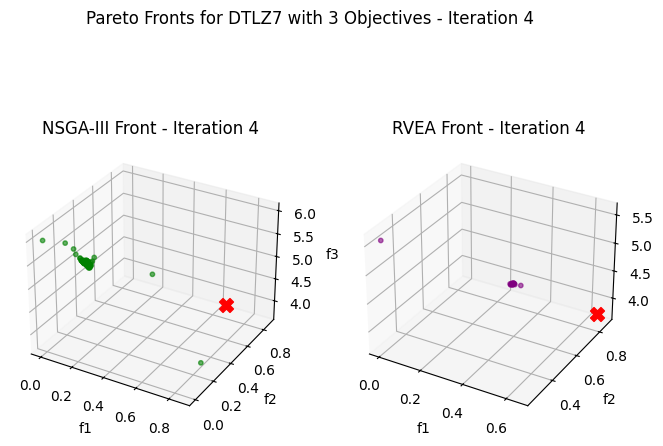

<Figure size 640x480 with 0 Axes>

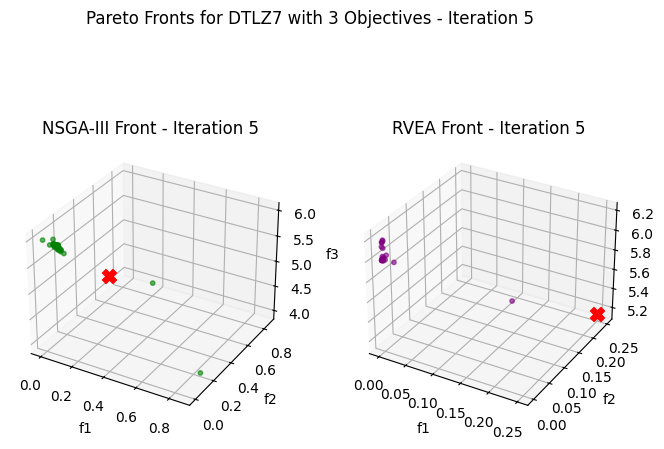

<Figure size 640x480 with 0 Axes>

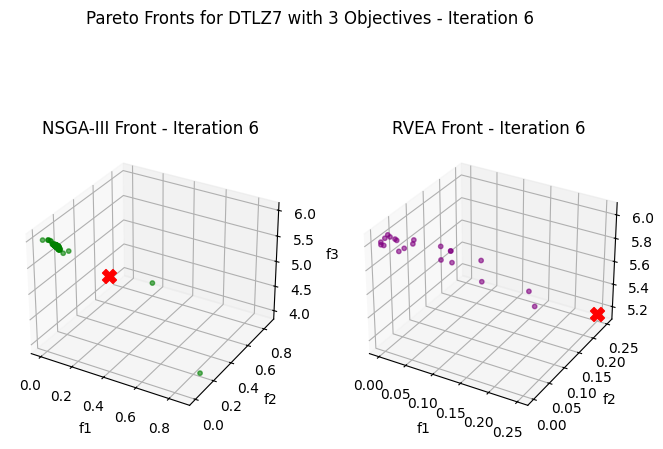

<Figure size 640x480 with 0 Axes>

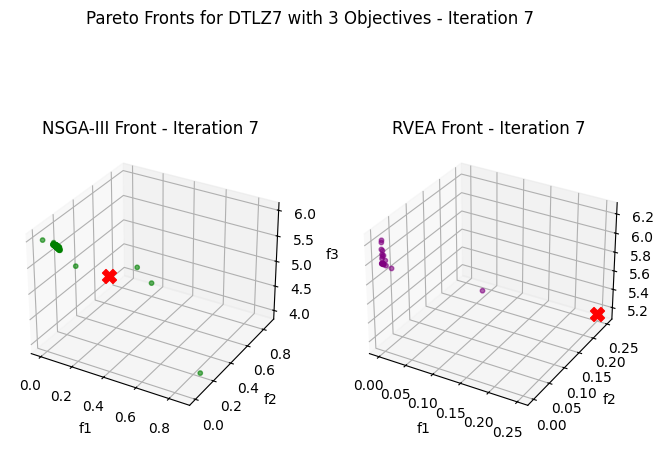

<Figure size 800x600 with 0 Axes>

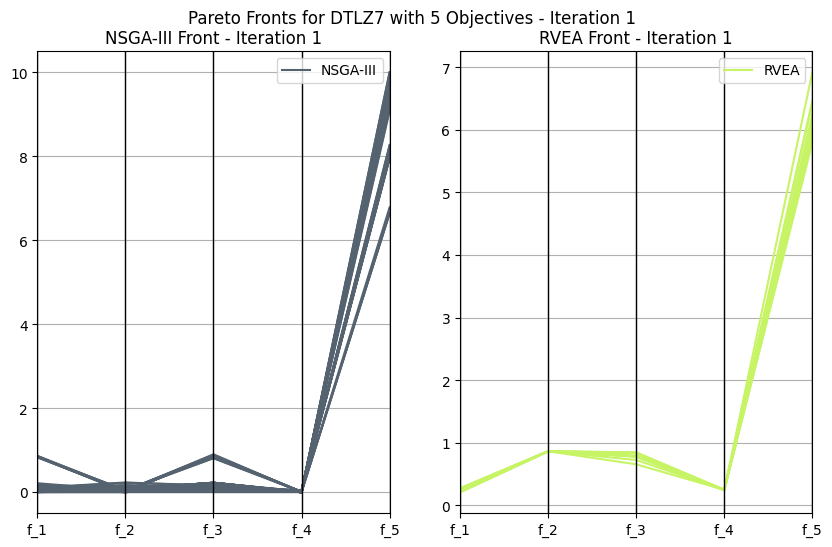

<Figure size 640x480 with 0 Axes>

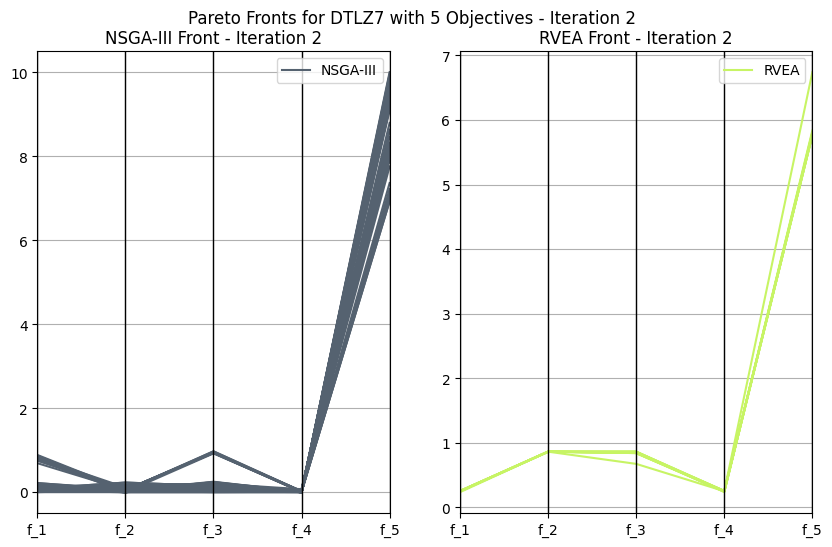

<Figure size 640x480 with 0 Axes>

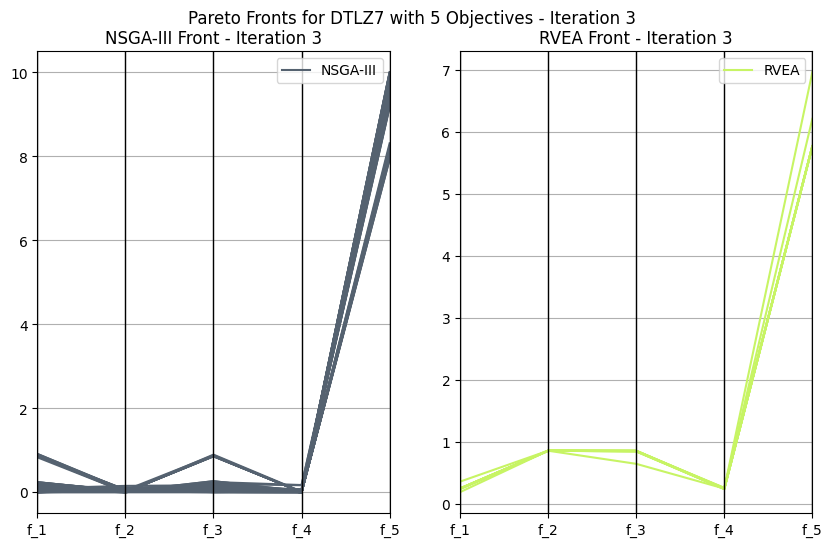

<Figure size 640x480 with 0 Axes>

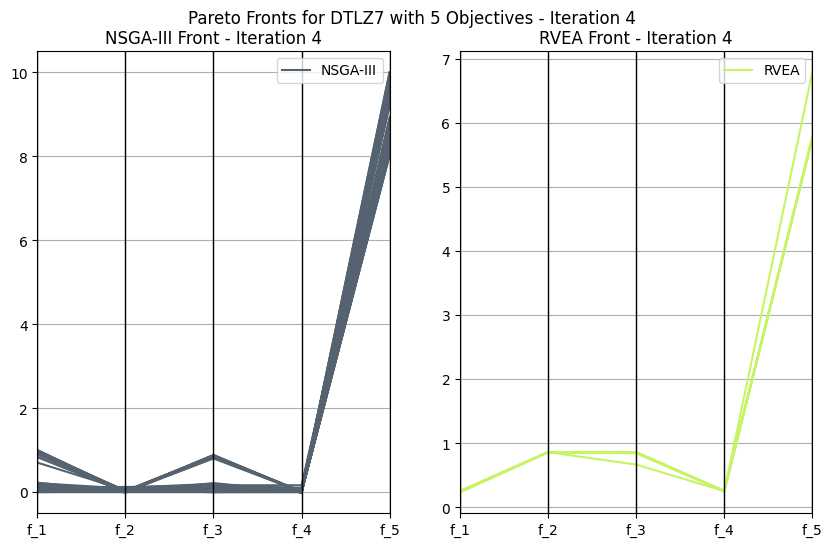

<Figure size 640x480 with 0 Axes>

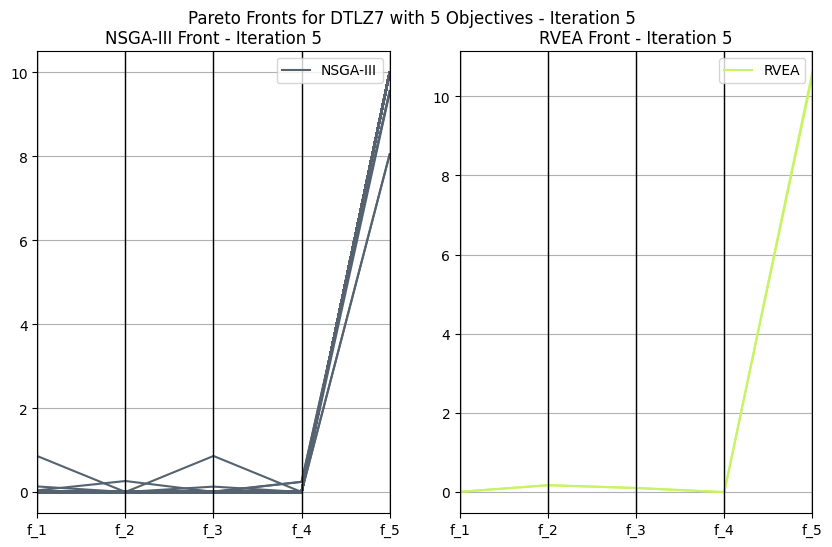

<Figure size 640x480 with 0 Axes>

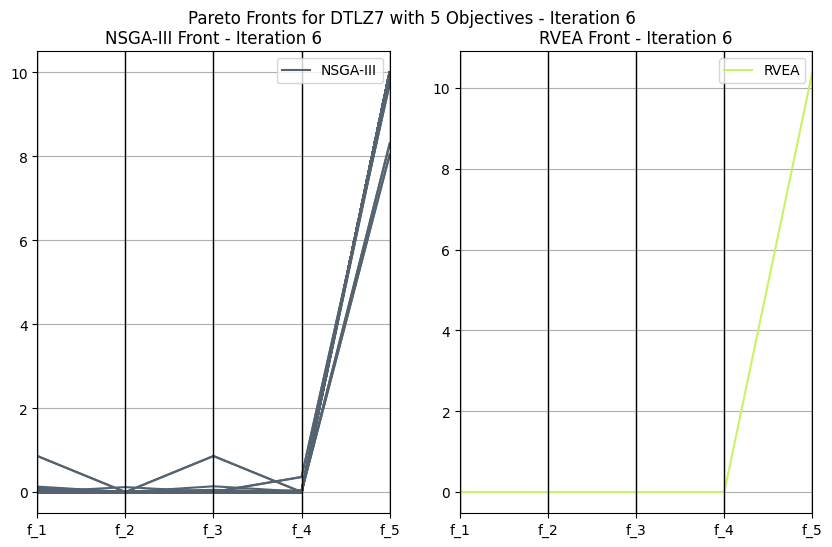

<Figure size 640x480 with 0 Axes>

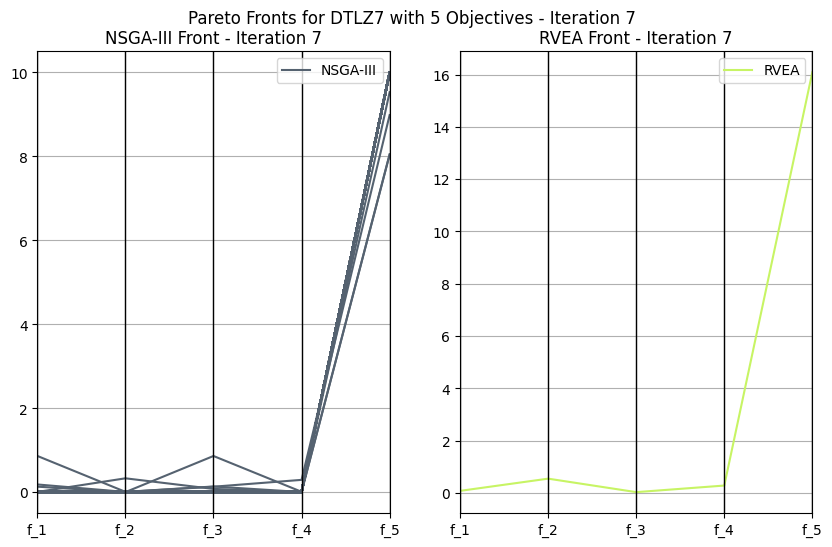

<Figure size 800x600 with 0 Axes>

In [ ]:
# Read the generated reference points and the corresponding Pareto fronts to visualize the ADM process.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
OUTPUT_DIR = "results"
import numpy as np

dtlz_problems = [f"dtlz{i}" for i in range(1, 8)]
wfg_problems = [f"wfg{i}" for i in range(1, 10)]
objective_counts = [3 , 5, 7]


# Visualizing the results
for name in dtlz_problems:
    for n_obj in objective_counts:
        ref_path = os.path.join(OUTPUT_DIR, f"{name}_{n_obj}obj_refpoints.csv")
        
        if not os.path.exists(ref_path):
            continue
        reference_points = pd.read_csv(ref_path)
        phases = reference_points["Phase"].values
        prefs = reference_points.drop(columns=["Phase"]).values

        fig = plt.figure(figsize=(8, 6))
        if n_obj == 3:
            # Make one plot for each iteration
            for i in range(len(reference_points)):
                plt.clf()
                fig = plt.figure(figsize=(8, 6))
                data_path_nsga3 = os.path.join(OUTPUT_DIR, f"nsga3_iteration_{name}_{n_obj}_{i+1}.csv")
                data_path_rvea = os.path.join(OUTPUT_DIR, f"rvea_iteration_{name}_{n_obj}_{i+1}.csv")
                data_nsga3 = pd.read_csv(data_path_nsga3)
                data_rvea = pd.read_csv(data_path_rvea)
                ax = fig.add_subplot(121, projection='3d')
                ax.scatter(data_nsga3.iloc[:,0], data_nsga3.iloc[:,1],
                            data_nsga3.iloc[:,2], c='green', s=10, alpha=0.6)
                #draw reference point
                ax.scatter(prefs[i,0], prefs[i,1], prefs[i,2], c='red', s=100, marker='X', label='ADM Reference Point')
                ax.set_title(f'NSGA-III Front - Iteration {i+1}')
                ax.set_xlabel('f1')
                ax.set_ylabel('f2')
                ax.set_zlabel('f3')
                ax2 = fig.add_subplot(122, projection='3d')
                ax2.scatter(data_rvea.iloc[:,0], data_rvea.iloc[:,1
                            ], data_rvea.iloc[:,2], c='purple', s=10, alpha=0.6)
                ax2.scatter(prefs[i,0], prefs[i,1], prefs[i,2], c='red', s=100, marker='X', label='ADM Reference Point')
                ax2.set_title(f'RVEA Front - Iteration {i+1}')
                ax2.set_xlabel('f1')
                ax2.set_ylabel('f2')
                ax2.set_zlabel('f3')
                plt.suptitle(f'Pareto Fronts for {name.upper()} with {n_obj} Objectives - Iteration {i+1}', y=0.95)
                plt.show()
            #ax = fig.add_subplot(111, projection='3d')
            #ax.scatter(prefs[:,0], prefs[:,1], prefs[:,2], c=['blue' if p == 'Learning' else 'orange' for p in phases])
            #ax.set_xlabel('f1 Preference')
            #ax.set_ylabel('f2 Preference')
            #ax.set_zlabel('f3 Preference')
            #ax.set_title(f'ADM Reference Points for {name.upper()} with {n_obj} Objectives')
        elif n_obj == 5:
            # Add a parallel coordinates plot for each iteration
            for i in range(len(reference_points)):
                plt.clf()
                fig = plt.figure(figsize=(10, 6))
                #get only f_1 to f_5 columns
                data_path_nsga3 = os.path.join(OUTPUT_DIR, f"nsga3_iteration_{name}_{n_obj}_{i+1}.csv")
                data_path_rvea = os.path.join(OUTPUT_DIR, f"rvea_iteration_{name}_{n_obj}_{i+1}.csv")
                data_nsga3 = pd.read_csv(data_path_nsga3)
                data_nsga3 = data_nsga3.iloc[:, :5]
                data_rvea = pd.read_csv(data_path_rvea)
                data_rvea = data_rvea.iloc[:, :5]
                plt.subplot(1, 2, 1)
                pd.plotting.parallel_coordinates(data_nsga3.assign(Phase='NSGA-III'), 'Phase', color=('#556270'))
                plt.title(f'NSGA-III Front - Iteration {i+1}')
                plt.subplot(1, 2, 2)
                pd.plotting.parallel_coordinates(data_rvea.assign(Phase='RVEA'), 'Phase', color=('#C7F464'))
                plt.title(f'RVEA Front - Iteration {i+1}')
                plt.suptitle(f'Pareto Fronts for {name.upper()} with {n_obj} Objectives - Iteration {i+1}', y=0.95)
                plt.show()
            #plt.figure(figsize=(10, 6))
            #pd.plotting.parallel_coordinates(reference_points, 'Phase', color=('#556270', '#C7F464'))
            #plt.title(f'ADM Reference Points Parallel Coordinates for {name.upper()} with {n_obj} Objectives')
            #plt.show()